# Project Introduction : Abuse

This notebook is a comprehensive analysis of abusive conduct on online,  user-generated tweets. The content includes: data loading, data cleaning, EDA, modeling and results interpretation

#**Table**

## Section 0: Imports and common functions
## Section 1: Data Loading
## Section 2: Text Cleaning
## Section 3: BERTopic
## Section 4: Excluding class 'other_cyberbullying'
## Section 5: Preprocessing and Splitting
## Section 6: EDA
## Section 7: Oversampling and Loading
## Section 8: Baseline model
## Section 9: TF-IDF + Logistic Regression
## Section 10: TF-IDF + XGBoost
## Section 11: Utilities
## Section 12: Text CNN
## Section 13: BiLSTM + Attention
## Section 14: GloVe CNN
## Section 15: GloVe BiLSTM
## Section 16: BERT
## Section 17: Results and interpretation
## Section 18: BERT Inference

## Section 0: Imports and common functions

In [ ]:
from pathlib import Path

Path("models").mkdir(exist_ok=True)


Before starting to work in the notebook, check the requirments.txt file with all the necessary material to operate. Check also the utils folder to explore common files functions, and its subfolder tasks for specific ones

To have a notebook as clean as possible, all the common functions between subdomains will be imported from the files in the utils subfolder on github. While domain-specific functions will be imported from specific file in tasks folder in the REPO.

In [ ]:
import os, sys, urllib.request
from pathlib import Path
from contextlib import redirect_stdout, redirect_stderr
import io

# ── Suppress all output (stdout and stderr) ───────────────────────────────────
f = io.StringIO()
with redirect_stdout(f), redirect_stderr(f):

    # Install required libraries quietly
    os.system("pip install -q gensim emoji contractions langdetect bertopic")
    os.system("pip install --upgrade xgboost --quiet")

    REPO_RAW = "https://raw.githubusercontent.com/boblaros/mago-text-scoring/main"

    # Create package structure
    UTILITIES_DIR = Path("mago/utils")
    UTILITIES_DIR.mkdir(parents=True, exist_ok=True)
    (UTILITIES_DIR / "__init__.py").touch()  # Make it a package

    TASKS_DIR = UTILITIES_DIR / "tasks"
    TASKS_DIR.mkdir(exist_ok=True)
    (TASKS_DIR / "__init__.py").touch()  # Make it a subpackage

    files_to_fetch = {
        # Files inside utils/
        UTILITIES_DIR / "training.py": f"{REPO_RAW}/utils/training.py",
        UTILITIES_DIR / "text.py": f"{REPO_RAW}/utils/text.py",
        UTILITIES_DIR / "plots.py": f"{REPO_RAW}/utils/plots.py",
        UTILITIES_DIR / "metrics.py": f"{REPO_RAW}/utils/metrics.py",
        UTILITIES_DIR / "data.py": f"{REPO_RAW}/utils/data.py",
        # Files inside utils/tasks/
        TASKS_DIR / "utils_abuse.py": f"{REPO_RAW}/utils/tasks/utils_abuse.py",
    }

    for local_path, url in files_to_fetch.items():
        urllib.request.urlretrieve(url, local_path)

        # Remove pip install lines from utils_abuse.py
        if "utils_abuse.py" in str(local_path):
            with open(local_path, 'r') as f_in:
                lines = f_in.readlines()
            with open(local_path, 'w') as f_out:
                for line in lines:
                    if not any(x in line for x in [
                        '!pip install emoji',
                        '!pip install contractions',
                        '!pip install langdetect',
                        '!pip install bertopic'
                    ]):
                        f_out.write(line)

    # Add the parent directory of 'utils' to sys.path
    if str(Path.cwd() / "mago") not in sys.path:
        sys.path.insert(0, str(Path.cwd() / "mago"))

    # Import modules from the package
    from utils.training import *
    from utils.text import *
    from utils.plots import *
    from utils.metrics import *
    from utils.data import *
    from utils.tasks.utils_abuse import *

# ── Final output only ─────────────────────────────────────────────────────────
print("All the functions have been correctly imported.")

All the functions have been correctly imported.


In [ ]:
# ── 0.1 Imports ─────────────────────────────────────────────────────────────
# Install necessary libraries first
import warnings
import logging
import contextlib
import sys
import os

# Silenziare warnings globali
warnings.filterwarnings("ignore")

# Silenziare logging di molti pacchetti
logging.getLogger().setLevel(logging.ERROR)

# Cattura eventuali print indesiderati dai pacchetti
with contextlib.redirect_stdout(open(os.devnull, "w")), \
     contextlib.redirect_stderr(open(os.devnull, "w")):

    # ── 0.1 Imports ─────────────────────────────────────────────
    # Librerie principali
    import os, sys, json, time, random
    from pathlib import Path
    from datetime import datetime
    from collections import Counter
    import shutil
    import matplotlib.pyplot as plt

    # Data & ML
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    from tqdm.auto import tqdm

    # Sklearn
    from sklearn.dummy import DummyClassifier
    from sklearn.linear_model import LogisticRegression
    from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
    from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score
    from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, roc_auc_score
    from sklearn.preprocessing import LabelEncoder

    # XGBoost
    from xgboost import XGBClassifier

    # Deep learning
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import Dataset, DataLoader
    from torch.utils.tensorboard import SummaryWriter
    from torch.optim import AdamW
    from torch.optim.lr_scheduler import ReduceLROnPlateau

    from sentence_transformers import SentenceTransformer
    from bertopic import BERTopic # Ensure BERTopic is imported
    import joblib # Ensure joblib is imported
    import torch # Import torch
    from sklearn.metrics.pairwise import cosine_similarity
    import numpy as np
    import torch
    import xgboost
    import utils.plots as _plots
    import utils.metrics as _metrics
    import utils.training as _training
    from sentence_transformers import SentenceTransformer
    from bertopic import BERTopic # Ensure BERTopic is imported
    import joblib # Ensure joblib is imported
    import torch # Import torch
    from sklearn.metrics.pairwise import cosine_similarity
    import numpy as np
    from sklearn.feature_extraction.text import TfidfVectorizer
    from scipy.sparse import hstack
    import matplotlib.pyplot as plt
    import xgboost


    # NLP
    import nltk
    from nltk.corpus import stopwords
    from nltk.stem import WordNetLemmatizer
    import re, string, emoji, contractions
    from langdetect import detect, LangDetectException
    from imblearn.over_sampling import RandomOverSampler
    import gensim.downloader as api
    import umap
    import hdbscan
    from bertopic import BERTopic
    from datasets import load_dataset
    from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification
    from transformers import TrainingArguments, Trainer, EarlyStoppingCallback
    from transformers.trainer_utils import get_last_checkpoint
    from scipy.sparse import hstack
    import networkx as nx
    from transformers import AutoTokenizer, AutoModelForSequenceClassification
    import torch


    # NLTK download silenzioso
    nltk.download(["stopwords", "wordnet", "punkt"], quiet=True)

# Stampiamo solo il messaggio finale
print("Imports OK")

Imports OK


In [ ]:
# Suppress pip output for quiet installs
!pip install --quiet transformers torch sentencepiece

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
path = "/content/drive/MyDrive/MAGO/CyberBulling_Classification/cyberbullying_tweets.csv"
# output folder
OUTPUT_DIR = Path("/content/drive/MyDrive/output")
print("Output directory:", OUTPUT_DIR)
#  models folder
MODELS_DIR = Path("/content/drive/MyDrive/output/models")
print("Models directory:", MODELS_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Output directory: /content/drive/MyDrive/output
Models directory: /content/drive/MyDrive/output/models


In [ ]:
OUTPUT_DIR = Path("/content/drive/MyDrive/output")
MODELS_DIR = Path("/content/drive/MyDrive/output/models")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTPUT_DIR)
print("Models directory:", MODELS_DIR)


try:
    # main: Hugging Face
    url = "https://huggingface.co/datasets/mattematics/cyberbullying/resolve/main/cyberbullying_tweets.csv"
    df_raw = pd.read_csv(url)
    print(" Dataset loaded from Hugging Face")
except Exception as e:
    # Fallback: Google Drive
    path = "/content/drive/MyDrive/MAGO/CyberBulling_Classification/cyberbullying_tweets.csv"
    df_raw = pd.read_csv(path)
    print(" Dataset loaded Google Drive (fallback)")


df_raw.head()

Output directory: /content/drive/MyDrive/output
Models directory: /content/drive/MyDrive/output/models
 Dataset loaded from Hugging Face


,tweet_text,cyberbullying_type
0,"In other words #katandandre, your food was cra...",not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying


We keep the task configuration, paths, toggles, and reproducibility settings in one place so reruns stay consistent and easy to audit.

In [ ]:
# ── 0.2 Global Configuration ─────────────────────────────────────────────────
CFG = {
    # ── Reproducibility
    "seed": 42,

    # ── Paths
    "data_dir":   Path("data/"),
    "output_dir": Path("outputs/"),
    "model_dir":  Path("models/"),
    "log_dir":    Path("logs/"),
    "output_paths": {
        "plots_comparison": Path("outputs/"),
        "plots_confusion":  Path("outputs/"),
        "plots_history":    Path("outputs/"),
        "metrics":          Path("outputs/"), # Added this line
    },

    # ── Task  ← CHANGE ONLY THIS BLOCK between notebooks
    # Options: sentiment_analysis | abuse_detection | (any classification task)
    "task":       "abuse_detection",
    "text_col":   "tweet_text",
    "label_col":  "cyberbullying_type",
    "num_labels": 5,

    # ── Split
    "test_size": 0.15,
    "val_size":  0.15,

    # ── Cross-validation
    "use_cv":   True,
    "cv_folds": 5,

    # ── TF-IDF
    "tfidf_word_ngrams": (1, 2),
    "use_char_ngrams":   True,
    "class_weight":      "balanced",

    # ── Embeddings
    "embedding_model": "glove-wiki-gigaword-100",  # or "fasttext-wiki-news-subwords-300"
    "embedding_dim":   100,
    "vocab_size":      30_000,
    "max_seq_len":     128,
    "pad_token":       "<PAD>",
    "unk_token":       "<UNK>",

    # ── Deep learning (CNN / BiLSTM / MLP)
    "dl_batch_size": 64,
    "dl_epochs":     20,
    "dl_lr":         1e-3,
    "dl_patience":   3,
    "dropout":       0.3,

    # ── CNN-specific
    "cnn_num_filters":  128,
    "cnn_kernel_sizes": [2, 3, 4],

    # ── BiLSTM-specific
    "lstm_hidden_dim": 128,
    "lstm_num_layers": 2,

    # ── Transformer
    "trf_model":  "bert-base-uncased",
    "max_len":    256,
    "batch_size": 16,
    "epochs":     5,
    "lr":         2e-5,

    # ── Device
    "device": (
        "mps"  if torch.backends.mps.is_available() and torch.backends.mps.is_built()
        else "cuda" if torch.cuda.is_available()
        else "cpu"
    )
}

# Create directories
for d in ["data_dir", "output_dir", "model_dir", "log_dir"]:
    CFG[d].mkdir(parents=True, exist_ok=True);

print(f"Task  : {CFG['task']}")
print(f"Labels: {CFG['num_labels']}")
print(f"Device: {CFG['device']}")

Task  : abuse_detection
Labels: 5
Device: cpu


In [ ]:

_plots.CFG = CFG
_metrics.CFG = CFG
_training.CFG = CFG
_plots.COLORS = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]
CFG['output_paths']['metrics'] = Path('outputs/metrics')

Set the seed for reproducibility

In [ ]:
set_seed(CFG["seed"])
print("Seed set.")

Seed set.


# Section 1: Data Loading

Labels counts are being inspected:

In [ ]:
df_raw = pd.read_csv(path)
label_counts = df_raw['cyberbullying_type'].value_counts()
print(label_counts)

cyberbullying_type
religion               7998
age                    7992
gender                 7973
ethnicity              7961
not_cyberbullying      7945
other_cyberbullying    7823
Name: count, dtype: int64


In [ ]:

df_raw['text_len'] = df_raw['tweet_text'].str.split().apply(len)

# Section 2 : Text Cleaning

Tweets can be quite a noisy and dirty observations: they can contain emojis, hashtags, links, numbers in the middle, and other expression that mislead or break the analysis. All this special characters will be removed with the help of the clean_tweet function defined in the task-dependent import file.

In [ ]:
# new column with cleaned text
df_raw['clean_text'] = df_raw['tweet_text'].apply(clean_tweet)

let's inspect the result:

In [ ]:
df_raw[['tweet_text', 'clean_text']].head(10)

,tweet_text,clean_text
0,"In other words #katandandre, your food was cra...",in other words katandandre your food was crapi...
1,Why is #aussietv so white? #MKR #theblock #ImA...,why is aussietv so white mkr theblock imaceleb...
2,@XochitlSuckkks a classy whore? Or more red ve...,classy whore or more red velvet cupcakes
3,"@Jason_Gio meh. :P thanks for the heads up, b...",meh thanks for the heads up but not too concer...
4,@RudhoeEnglish This is an ISIS account pretend...,this is an isis account pretending to be kurdi...
5,"@Raja5aab @Quickieleaks Yes, the test of god i...",yes the test of god is that good or bad or ind...
6,Itu sekolah ya bukan tempat bully! Ga jauh kay...,
7,Karma. I hope it bites Kat on the butt. She is...,karma hope it bites kat on the butt she is jus...
8,@stockputout everything but mostly my priest,everything but mostly my priest
9,Rebecca Black Drops Out of School Due to Bully...,rebecca black drops out of school due to bullying


also duplicated tweets are being removed

In [ ]:
# Removes duplicates, keeps first occurrence
df_raw = df_raw.drop_duplicates(subset='clean_text', keep='first').reset_index(drop=True)

In [ ]:
# shows how many clean tweets are duplicates
print(df_raw['clean_text'].duplicated().sum())

0


In [ ]:
print(df_raw.shape)
print(df_raw.head(10))

(42361, 4)
                                          tweet_text cyberbullying_type  \
0  In other words #katandandre, your food was cra...  not_cyberbullying   
1  Why is #aussietv so white? #MKR #theblock #ImA...  not_cyberbullying   
2  @XochitlSuckkks a classy whore? Or more red ve...  not_cyberbullying   
3  @Jason_Gio meh. :P  thanks for the heads up, b...  not_cyberbullying   
4  @RudhoeEnglish This is an ISIS account pretend...  not_cyberbullying   
5  @Raja5aab @Quickieleaks Yes, the test of god i...  not_cyberbullying   
6  Itu sekolah ya bukan tempat bully! Ga jauh kay...  not_cyberbullying   
7  Karma. I hope it bites Kat on the butt. She is...  not_cyberbullying   
8       @stockputout everything but mostly my priest  not_cyberbullying   
9  Rebecca Black Drops Out of School Due to Bully...  not_cyberbullying   

   text_len                                         clean_text  
0         9  in other words katandandre your food was crapi...  
1        14  why is aussietv so w

In [ ]:
class_counts = df_raw['cyberbullying_type'].value_counts()
print(class_counts)

cyberbullying_type
religion               7934
age                    7886
ethnicity              7462
gender                 7386
not_cyberbullying      6417
other_cyberbullying    5276
Name: count, dtype: int64


In [ ]:
class_percent = df_raw['cyberbullying_type'].value_counts(normalize=True) * 100
print(class_percent)

cyberbullying_type
religion               18.729492
age                    18.616180
ethnicity              17.615259
gender                 17.435849
not_cyberbullying      15.148368
other_cyberbullying    12.454852
Name: proportion, dtype: float64


# Section 3: BERTOPIC

In previous analysis not reported on this notebook, the most problematic class was "other cyberbullying". In classification tasks previously carried out ,it was the most misclassified task, without an apparent reason. It feels worthwile to understand if this class is treated as a "bin" in which ambiguos text are stored, or if it contains some "signal" about other cyberbullying forms to take into actual account

In [ ]:

df_raw["clean_text"] = df_raw["tweet_text"].apply(clean_tweet)


df_raw = df_raw.drop_duplicates(subset="clean_text", keep="first").reset_index(drop=True)

# # Filter only the "other_cyberbullying" class for analysis
df_other = df_raw[df_raw["cyberbullying_type"] == "other_cyberbullying"].copy()

Generate sentence embeddings for the selected documents.

In [ ]:

embedding_model = SentenceTransformer("all-MiniLM-L6-v2", device=CFG["device"])

documents = df_other["clean_text"].tolist()

embeddings = embedding_model.encode(
    documents,
    show_progress_bar=True
)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/164 [00:00<?, ?it/s]

Reduce embedding dimensionality using UMAP.

In [ ]:


umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

Cluster embeddings using HDBSCAN.

In [ ]:


hdbscan_model = HDBSCAN(
    min_cluster_size=80,
    min_samples=10,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

Vectorize text to extract topic keywords.

In [ ]:
vectorizer_model = CountVectorizer(
    ngram_range=(1, 2),
    stop_words="english",
    min_df=5,
    max_df=0.9
)

Train the BERTopic model and save outputs.

In [ ]:

# Ensure the output directory for models exists
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Create and train BERTOPIC
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    calculate_probabilities=True,
    verbose=True
)

topics, probs = topic_model.fit_transform(documents, embeddings)

topic_model.save(MODELS_DIR / "bertopic_model")


joblib.dump(embeddings, MODELS_DIR / "bertopic_embeddings.pkl")

2026-03-17 17:17:36,916 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-17 17:17:58,922 - BERTopic - Dimensionality - Completed ✓
2026-03-17 17:17:58,924 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-17 17:17:59,243 - BERTopic - Cluster - Completed ✓
2026-03-17 17:17:59,247 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-17 17:17:59,358 - BERTopic - Representation - Completed ✓
2026-03-17 17:17:59,418 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


['/content/drive/MyDrive/output/models/bertopic_embeddings.pkl']

Reload the model safely on CPU.

In [ ]:
embedding_model_cpu = SentenceTransformer("all-MiniLM-L6-v2", device=CFG["device"])

# Store original torch.load
_original_torch_load = torch.load

# Define a wrapper for torch.load to always map to CPU
def _wrapped_torch_load(*args, **kwargs):
    kwargs['map_location'] = 'cpu'
    return _original_torch_load(*args, **kwargs)

# Temporarily replace torch.load
torch.load = _wrapped_torch_load

try:

    # and explicitly mapping all internal tensors to CPU (via monkey-patch)
    topic_model = BERTopic.load(
        MODELS_DIR / "bertopic_model",
        embedding_model=embedding_model_cpu
    )
finally:
    # Restore original torch.load after loading
    torch.load = _original_torch_load

embeddings = joblib.load(MODELS_DIR / "bertopic_embeddings.pkl")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Inspect the number of topics and outliers.

In [ ]:
topics = topic_model.topics_
probs = topic_model.probabilities_
print(f"Number of topics: {len(set(topics)) - 1}")
print(f"Outliers: {topics.count(-1)} ({100*topics.count(-1)/len(topics):.1f}%)")

Number of topics: 14
Outliers: 2010 (38.4%)


Display the top topics with their sizes and representative keywords.

In [ ]:
topic_model.get_topic_info().head(10)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2010,-1_people_hate_amp_ass,"[people, hate, amp, ass, bad, fuck, got, perso...",[pray for nem on that appeal man fuck da feds ...
1,0,835,0_bully_bullying_lol_stop,"[bully, bullying, lol, stop, got, school, peop...","[my mommy is such bully, me either bully, rees..."
2,1,449,1_women_white_woman_called,"[women, white, woman, called, use, word, peopl...",[no kidding would love to see more deep storyl...
3,2,288,2_twitter_tweet_tweets_account,"[twitter, tweet, tweets, account, block, block...","[why does your twitter name have testicles, do..."
4,3,275,3_idiot_idiots_stupid_team,"[idiot, idiots, stupid, team, run, war, damn, ...","[is fucking idiot, did because am an idiot, no..."
5,4,213,4_hate_ass_bitch_bad,"[hate, ass, bitch, bad, shit, annoying, rt jus...",[want to hate tim tebow so bad but he is the n...
6,5,198,5_round_amp_looks_girls,"[round, amp, looks, girls, looks like, little,...",[it is going to girls round on mkr this week b...
7,6,197,6_house_week_stuff_live,"[house, week, stuff, live, thank, tomorrow, la...",[moving to pdx early august need house near ci...
8,7,166,7_code_script_use_hit,"[code, script, use, hit, air, worked, used, ru...","[apple mostly uses bsd licensed code, that is ..."
9,8,135,8_harassment_abuse_targeted_online,"[harassment, abuse, targeted, online, report, ...",[til that feminists or group of people targete...


Show the top keywords defining topic 0

In [ ]:
topic_model.get_topic(0)

[('bully', np.float64(0.17850769362354194)),
 ('bullying', np.float64(0.10262429434937964)),
 ('lol', np.float64(0.06592731252002448)),
 ('stop', np.float64(0.0377946469305396)),
 ('got', np.float64(0.035499716489131174)),
 ('school', np.float64(0.03432209051420881)),
 ('people', np.float64(0.02969861610623086)),
 ('big', np.float64(0.02397683078071349)),
 ('getting', np.float64(0.022746118377706438)),
 ('little', np.float64(0.021955262120151725))]

Display a few representative documents for topic 0.

In [ ]:
representative_docs = topic_model.get_representative_docs()

for i, doc in enumerate(representative_docs[0][:3]):
    print(f"Doc {i+1}: {doc[:300]}\n")

Doc 1: my mommy is such bully

Doc 2: me either bully

Doc 3: reese you are bully



Reduce outliers by reassigning them based on embedding similarity.

In [ ]:
print(f"Outliers before: {topics.count(-1)}")

new_topics = topic_model.reduce_outliers(
    documents,
    topics,
    strategy="embeddings"
)

print(f"Outliers after: {list(new_topics).count(-1)}")

Outliers before: 2010
Outliers after: 0


# BERTOPIC results

Visualize document clusters in a 2D space.

In [ ]:
topic_model.visualize_documents(documents)

In [ ]:
print(f"Shape of df_other (documents for BERTopic): {df_other.shape}")

Shape of df_other (documents for BERTopic): (5240, 4)


Intertopic distance visualization

In [ ]:
topic_model.visualize_topics()

Hierarchical clustering visualization

In [ ]:

topic_model.visualize_hierarchy()

Visualize the top topics with their most important keywords.

In [ ]:

topic_model.visualize_barchart(top_n_topics=10)

In [ ]:
fig = topic_model.visualize_documents(documents)
fig.write_html(MODELS_DIR / "topic_documents.html")

fig2 = topic_model.visualize_topics()
fig2.write_html(MODELS_DIR / "topics_map.html")

In [ ]:
new_topics = topic_model.reduce_outliers(documents, topics, strategy="embeddings")
print("Outliers after:", list(new_topics).count(-1))

Outliers after: 0


Compute cosine similarity between topic embeddings and identify topic pairs that are highly similar (similarity ≥ 0.75).

In [ ]:
topic_embeddings = topic_model.topic_embeddings_

similarity_matrix = cosine_similarity(topic_embeddings)


topic_ids = [t for t in topic_model.get_topic_info()["Topic"] if t != -1]


threshold = 0.75
similar_pairs = []

for i, tid1 in enumerate(topic_ids):
    for j, tid2 in enumerate(topic_ids):
        if i < j and similarity_matrix[tid1, tid2] >= threshold:
            similar_pairs.append((tid1, tid2))

print("Topic pairs with similarity >= 0.75:", similar_pairs)

Topic pairs with similarity >= 0.75: []


Calculate topic frequencies, add their percentage of total documents, and list the top keywords for each topic to better understand their content.

In [ ]:

total_docs = len(documents)


topic_freq = topic_model.get_topic_freq()
topic_freq['Percentage'] = 100 * topic_freq['Count'] / total_docs


top_words = []
for topic_id in topic_freq['Topic']:
    if topic_id == -1:
        top_words.append(["-"])
    else:
        words = [w for w, _ in topic_model.get_topic(topic_id)[:10]]
        top_words.append(words)

topic_freq['Top_Words'] = top_words

topic_freq_sorted = topic_freq.sort_values(by='Count', ascending=False).reset_index(drop=True)
topic_freq_sorted.head(15)

,Topic,Count,Percentage,Top_Words
0,-1,2010,38.358779,[-]
1,0,835,15.935115,"[bully, bullying, lol, stop, got, school, peop..."
2,1,449,8.568702,"[women, white, woman, called, use, word, peopl..."
3,2,288,5.496183,"[twitter, tweet, tweets, account, block, block..."
4,3,275,5.248092,"[idiot, idiots, stupid, team, run, war, damn, ..."
5,4,213,4.064885,"[hate, ass, bitch, bad, shit, annoying, rt jus..."
6,5,198,3.778626,"[round, amp, looks, girls, looks like, little,..."
7,6,197,3.759542,"[house, week, stuff, live, thank, tomorrow, la..."
8,7,166,3.167939,"[code, script, use, hit, air, worked, used, ru..."
9,8,135,2.576336,"[harassment, abuse, targeted, online, report, ..."


This table shows the distribution of topics in the dataset. Topic -1 represents outliers (38% of documents), while the other topics have varying frequencies and representative keywords that summarize their main themes, giving insight into the content and focus of each cluster.

The “other_cyberbullying” class appears highly heterogeneous and largely uninformative. BERTopic analysis shows that a significant portion of its documents (Topic -1) are unclustered outliers, indicating that they do not share coherent patterns with other texts. The remaining topics within this class are comparatively small, each representing only a minor fraction of the data, and do not form meaningful, consistent clusters. Given this distribution, retaining the class is likely to introduce noise and ambiguity into downstream classification tasks. Therefore, it is reasonable to remove the entire “other_cyberbullying” class, as it neither contributes clear patterns nor provides sufficient examples to model reliably.

#Section 4: exluding class other cyberbullying

Remove all documents labeled as “other_cyberbullying” from the dataset

In [ ]:
df = df_raw[df_raw["cyberbullying_type"] != "other_cyberbullying"]

Check the number of documents remaining in each cyberbullying class after removing “other_cyberbullying”.

In [ ]:
df["cyberbullying_type"].value_counts()

,count
cyberbullying_type,
religion,7924
age,7885
ethnicity,7400
gender,7365
not_cyberbullying,6359


# Section 5: Preprocessing and Splitting

define text preprocessing functions: normalize_text for minimal cleaning (keeps casing and punctuation for Transformers) and preprocess for full cleaning with stopword removal and lemmatization.

In [ ]:
# ── 2.1 Preprocessing Functions ──────────────────────────────────────────────
STOP = set(stopwords.words("english"))  # [TASK-SPECIFIC] change language if needed
lemmatizer = WordNetLemmatizer()

def normalize_text(text: str) -> str:
    """
    Minimal cleaning — used as input for Transformers.
    Keeps punctuation and casing information the subword tokenizer relies on.
    """
    text = str(text).lower()
    text = unicodedata.normalize("NFKD", text)
    text = re.sub(r"http\S+|www\S+", " ", text)          # URLs
    text = re.sub(r"@\w+|#\w+", " ", text)                # mentions / hashtags
    text = re.sub(r"[^a-zA-Z0-9\s!?.,\'\']", " ", text)   # special chars
    text = re.sub(r"\s+", " ", text).strip()
    return text


def preprocess(text: str,
               remove_stopwords: bool = True,
               lemmatize: bool = True) -> str:
    """
    Full cleaning — used for classical ML and embedding-based models.
    Applies stopword removal and lemmatization on top of normalize_text.
    """
    text   = normalize_text(text)
    tokens = text.split()
    if remove_stopwords:
        tokens = [t for t in tokens if t not in STOP]
    if lemmatize:
        tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)


# Smoke test
sample = "This is a GREAT movie!! http://example.com @user #review"
print("Raw         :", sample)
print("Normalized  :", normalize_text(sample))
print("Preprocessed:", preprocess(sample))

Raw         : This is a GREAT movie!! http://example.com @user #review
Normalized  : this is a great movie!!
Preprocessed: great movie!!


Apply full and minimal text preprocessing, remove missing and duplicate entries, and encode labels for modeling.

In [ ]:

# Preprocessing
tqdm.pandas(desc="Preprocessing")
df["text_clean"] = df[CFG["text_col"]].progress_apply(preprocess)     # full cleaning per ML/CNN/RNN
df["text_raw"]   = df[CFG["text_col"]].progress_apply(normalize_text) # minimal cleaning per Transformers

# Drop missing / duplicate
df = df.dropna(subset=[CFG["text_col"], CFG["label_col"]])
df = df.drop_duplicates(subset=[CFG["text_col"]])
print(f"Final dataset size: {len(df)}")

# Encode Labels
le = LabelEncoder()
df["label_enc"] = le.fit_transform(df[CFG["label_col"]])
print("Class mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

df.head(1)

Preprocessing:   0%|          | 0/36933 [00:00<?, ?it/s]

Preprocessing:   0%|          | 0/36933 [00:00<?, ?it/s]

Final dataset size: 36933
Class mapping: {'age': np.int64(0), 'ethnicity': np.int64(1), 'gender': np.int64(2), 'not_cyberbullying': np.int64(3), 'religion': np.int64(4)}


,tweet_text,cyberbullying_type,text_len,clean_text,text_clean,text_raw,label_enc
0,"In other words #katandandre, your food was cra...",not_cyberbullying,9,in other words katandandre your food was crapi...,"word , food crapilicious!","in other words , your food was crapilicious!",3


List the top 10 keywords for each active (non-outlier) topic to understand their main themes.

In [ ]:
topic_info = topic_model.get_topic_info()
active_topic_ids = topic_info[topic_info.Topic != -1]['Topic'].tolist()

for i in active_topic_ids:
    topic_words = topic_model.get_topic(i)
    # Ensure topic_words is a list before subscripting
    if isinstance(topic_words, list):
        print(f"Topic {i}: {topic_words[:10]}")  # prime 10 parole
    else:
        print(f"Topic {i}: Unexpected return type from get_topic - {type(topic_words)}")

Topic 0: [('bully', np.float64(0.17850769362354194)), ('bullying', np.float64(0.10262429434937964)), ('lol', np.float64(0.06592731252002448)), ('stop', np.float64(0.0377946469305396)), ('got', np.float64(0.035499716489131174)), ('school', np.float64(0.03432209051420881)), ('people', np.float64(0.02969861610623086)), ('big', np.float64(0.02397683078071349)), ('getting', np.float64(0.022746118377706438)), ('little', np.float64(0.021955262120151725))]
Topic 1: [('women', np.float64(0.15008296381313338)), ('white', np.float64(0.05661939128304543)), ('woman', np.float64(0.04599341062223883)), ('called', np.float64(0.04139928268679928)), ('use', np.float64(0.04074625172025029)), ('word', np.float64(0.038678514639099486)), ('people', np.float64(0.03326567585270922)), ('good', np.float64(0.03127543772948296)), ('tech', np.float64(0.029442083467183626)), ('problem', np.float64(0.024728196069046193))]
Topic 2: [('twitter', np.float64(0.18624371937461923)), ('tweet', np.float64(0.0935766906523558

Perform a stratified train/validation/test split to preserve class distribution, prepare text and label arrays for different model types, and set up a stratified K-fold cross-validation object.

In [ ]:
# ── 3.1 Stratified Split ──────────────────────────────────────────────────────
df_train_full, df_test = train_test_split(
    df,
    test_size=CFG["test_size"],
    random_state=CFG["seed"],
    stratify=df["label_enc"],
)

df_train, df_val = train_test_split(
    df_train_full,
    test_size=CFG["val_size"] / (1 - CFG["test_size"]),
    random_state=CFG["seed"],
    stratify=df_train_full["label_enc"],
)

# Reset indices — important for DataLoader alignment
df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

print(f"Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")

# ── 3.2 Shared Arrays ────────────────────────────────────────────────────────
# Classical ML & CNN/RNN → preprocessed text
X_train = df_train["text_clean"].values
X_val   = df_val["text_clean"].values
X_test  = df_test["text_clean"].values

# Transformers → minimally cleaned text
X_train_raw = df_train["text_raw"].values
X_val_raw   = df_val["text_raw"].values
X_test_raw  = df_test["text_raw"].values

y_train = df_train["label_enc"].values
y_val   = df_val["label_enc"].values
y_test  = df_test["label_enc"].values

# ── 3.3 Cross-Validation Object ──────────────────────────────────────────────
cv = StratifiedKFold(
    n_splits=CFG["cv_folds"],
    shuffle=True,
    random_state=CFG["seed"]
)

Train: 25853 | Val: 5540 | Test: 5540


# Section 6: EDA

In [ ]:
print("Missing values:\n", df_raw.isnull().sum())
print("\nDuplicated rows:", df_raw.duplicated().sum())


print("\nEmpty texts:", (df_raw["tweet_text"].str.strip() == "").sum())

Missing values:
 tweet_text            0
cyberbullying_type    0
text_len              0
clean_text            0
dtype: int64

Duplicated rows: 0

Empty texts: 0


Inspect basic statistics of tweet lengths to understand the distribution of text lengths in the dataset.

In [ ]:
df_raw["text_len"].describe()

,text_len
count,42173.000000
mean,25.486283
std,15.312593
min,3.000000
25%,15.000000
50%,22.000000
75%,36.000000
max,790.000000


*Compute and display the 20 most frequent words in the raw tweets to get a sense of common vocabulary.*


In [ ]:
all_words = " ".join(df_raw["tweet_text"]).lower().split()
common_words = Counter(all_words).most_common(20)

print(common_words)

[('the', 29965), ('a', 23674), ('to', 22552), ('and', 20990), ('i', 19232), ('you', 16508), ('of', 14897), ('in', 14441), ('is', 13329), ('that', 10693), ('are', 8675), ('for', 8308), ('school', 6989), ('not', 6820), ('it', 6516), ('my', 6450), ('was', 6367), ('me', 6348), ('but', 5986), ('this', 5859)]


Visualize the distribution of text lengths across cyberbullying classes using a boxplot (outliers hidden) to compare typical tweet sizes by class.

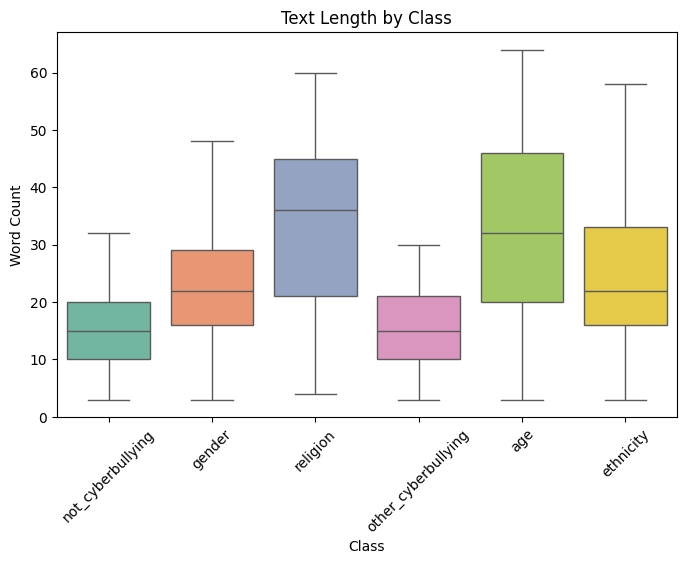

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_raw,
    x="cyberbullying_type",
    y="text_len",
    palette="Set2",
    showfliers=False
)

plt.xticks(rotation=45)
plt.title("Text Length by Class")
plt.xlabel("Class")
plt.ylabel("Word Count")

plt.savefig(OUTPUT_DIR / "text_length_by_class_boxplot.png", dpi=300, bbox_inches="tight")

plt.show()

Calculate the proportion of stopwords in the dataset to understand how much common filler words appear in the text

In [ ]:
stop_words = set(stopwords.words("english"))

stop_count = sum(word in stop_words for word in all_words)
print("Stopword ratio:", stop_count / len(all_words))

Stopword ratio: 0.4058500250736626


Extract the 20 most frequent bigrams from the raw tweets to identify common word pairs in the dataset.

In [ ]:


vectorizer = CountVectorizer(ngram_range=(2,2), max_features=20)

X = vectorizer.fit_transform(df_raw["tweet_text"])

print(vectorizer.get_feature_names_out())

['all the' 'ass nigger' 'bullied me' 'dumb ass' 'high school' 'http co'
 'if you' 'in high' 'in the' 'islamic terrorism' 'me in' 'of the' 'on the'
 'rape jokes' 'this is' 'to be' 'to the' 'who bullied' 'you are' 'you re']


Plot the top 20 most frequent bigrams in the dataset to visualize common word pair patterns in the tweets.

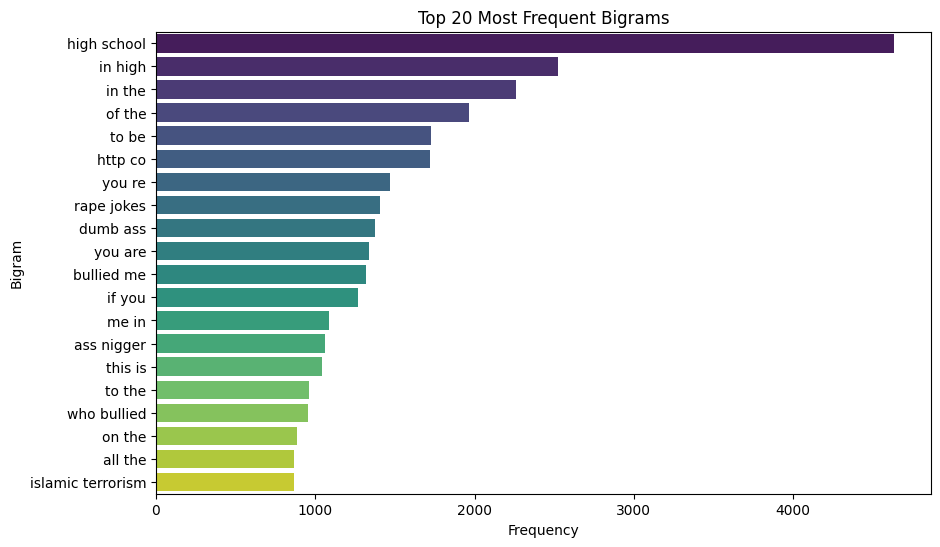

In [ ]:


bigram_counts = X.sum(axis=0).A1
bigram_names = vectorizer.get_feature_names_out()
bigram_freq = pd.DataFrame({
    'bigram': bigram_names,
    'count': bigram_counts
})
bigram_freq = bigram_freq.sort_values(by='count', ascending=False).head(20)


plt.figure(figsize=(10,6))
sns.barplot(
    data=bigram_freq,
    x="count",
    y="bigram",
    palette="viridis"
)

plt.title("Top 20 Most Frequent Bigrams")
plt.xlabel("Frequency")
plt.ylabel("Bigram")

plt.savefig(OUTPUT_DIR / "top20_bigrams.png", dpi=300, bbox_inches="tight")




Visualize the dataset with two plots: the first shows the distribution of labels (number of documents per class), and the second shows the distribution of text lengths by class for tweets up to 100 words.

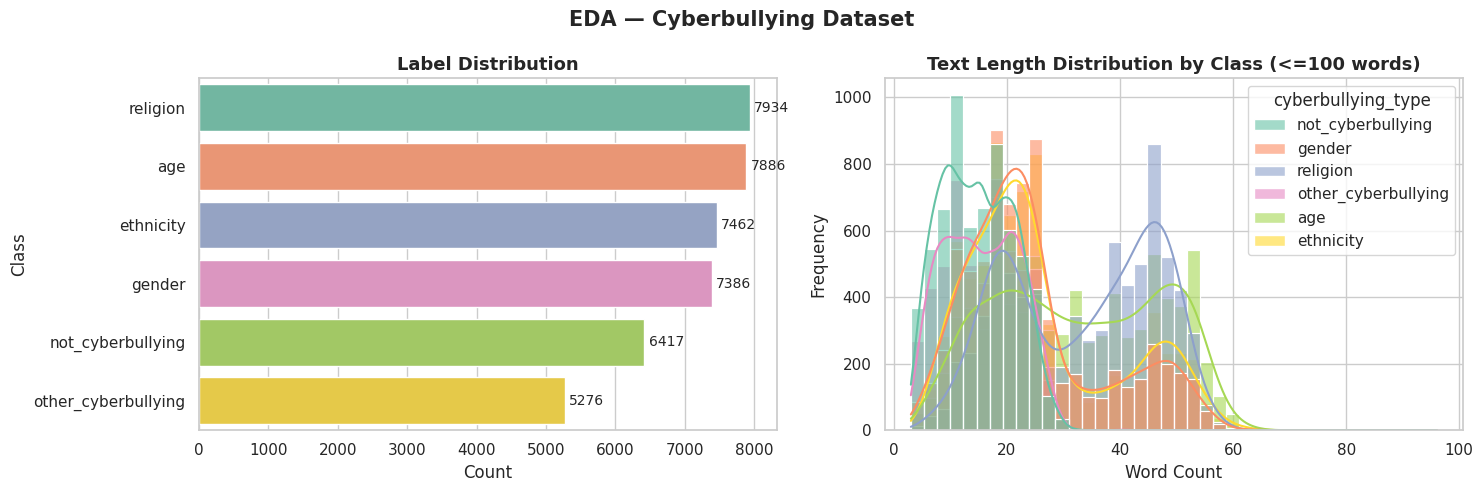

In [ ]:
# text len
df_raw['text_len'] = df_raw['tweet_text'].str.split().apply(len)

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

order = df_raw["cyberbullying_type"].value_counts().index


sns.countplot(
    data=df_raw,
    y="cyberbullying_type",
    order=order,
    palette="Set2",
    ax=axes[0]
)

axes[0].set_title("Label Distribution", fontsize=13, weight="bold")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Class")

for container in axes[0].containers:
    axes[0].bar_label(container, padding=3, fontsize=10)


sns.histplot(
    data=df_raw[df_raw['text_len'] <= 100],
    x="text_len",
    hue="cyberbullying_type",
    bins=40,
    kde=True,
    palette="Set2",
    alpha=0.6,
    ax=axes[1]
)

axes[1].set_title("Text Length Distribution by Class (<=100 words)", fontsize=13, weight="bold")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Frequency")

plt.suptitle("EDA — Cyberbullying Dataset", fontsize=15, weight="bold")
plt.tight_layout()


plt.savefig(OUTPUT_DIR / "eda_class_distribution_text_length.png", dpi=300, bbox_inches="tight")

plt.show()

Plot the top 10 most frequent words for each cyberbullying class to visualize class-specific vocabulary patterns.

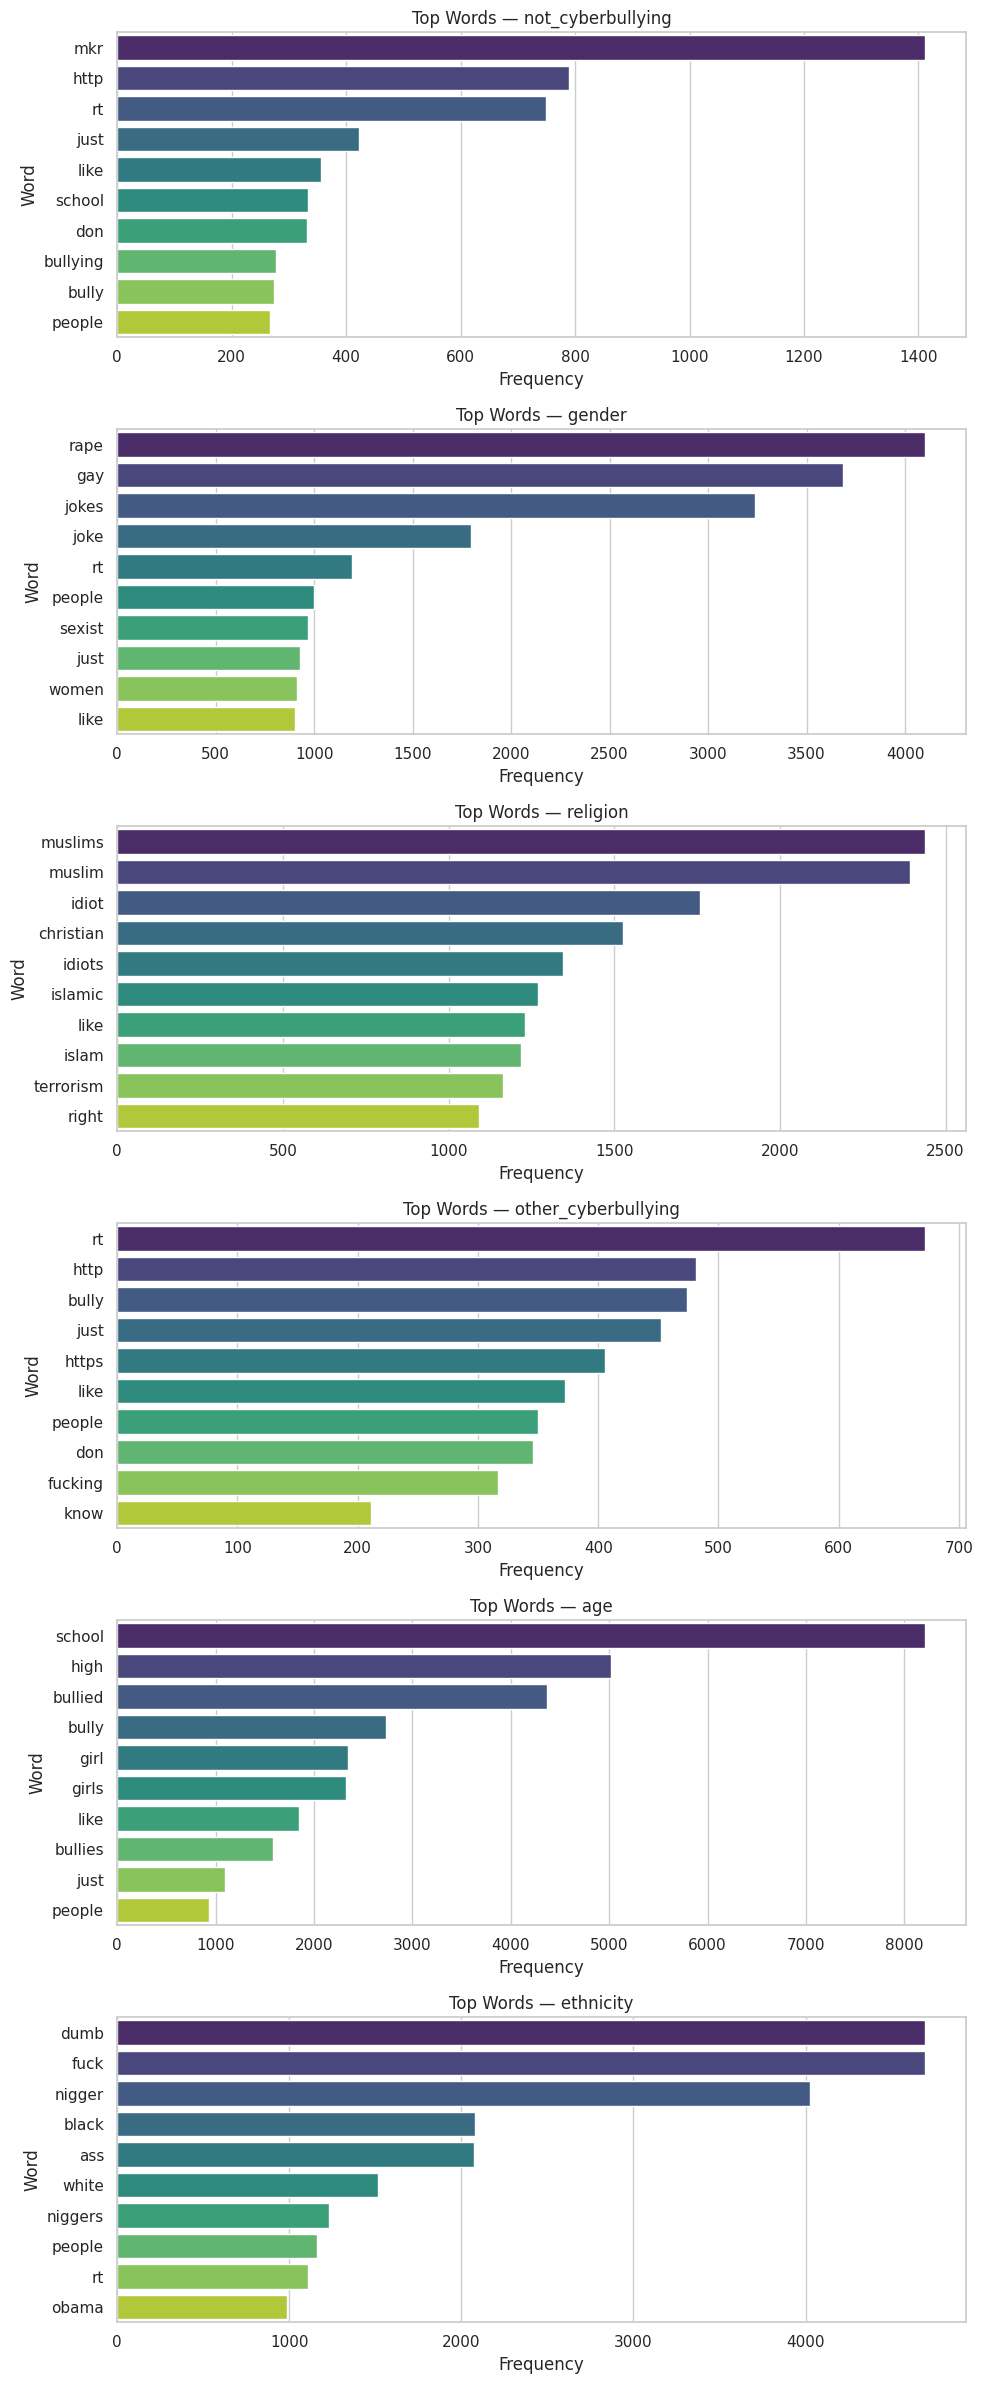

In [ ]:

vectorizer = CountVectorizer(
    stop_words="english",
    max_features=1000
)

X = vectorizer.fit_transform(df_raw["tweet_text"])
words = vectorizer.get_feature_names_out()

word_counts = pd.DataFrame(
    X.toarray(),
    columns=words
)

word_counts["label"] = df_raw["cyberbullying_type"].values

classes = word_counts["label"].unique()

fig, axes = plt.subplots(len(classes), 1, figsize=(10, 4*len(classes)))

for i, label in enumerate(classes):

    subset = word_counts[word_counts["label"] == label]

    top_words = (
        subset.drop(columns="label")
        .sum()
        .sort_values(ascending=False)
        .head(10)
    )

    sns.barplot(
        x=top_words.values,
        y=top_words.index,
        ax=axes[i],
        palette="viridis"
    )

    axes[i].set_title(f"Top Words — {label}")
    axes[i].set_xlabel("Frequency")
    axes[i].set_ylabel("Word")

plt.tight_layout()


plt.savefig(OUTPUT_DIR / "top_words_per_class.png", dpi=300, bbox_inches="tight")

plt.show()

Create a heatmap showing the frequencies of the top 20 words across each class to compare vocabulary usage between classes.

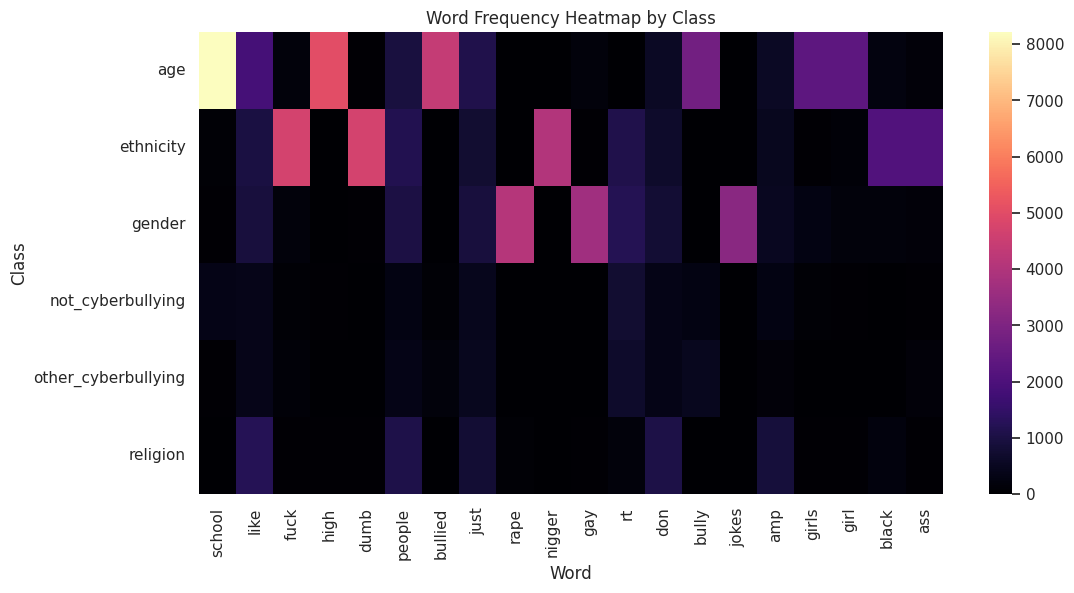

In [ ]:
top_matrix = word_counts.groupby("label").sum()

top_matrix = top_matrix.loc[:, top_matrix.sum().sort_values(ascending=False)[:20].index]

plt.figure(figsize=(12,6))

sns.heatmap(
    top_matrix,
    cmap="magma"
)

plt.title("Word Frequency Heatmap by Class")
plt.xlabel("Word")
plt.ylabel("Class")


plt.savefig(OUTPUT_DIR / "word_frequency_heatmap_by_class.png", dpi=300, bbox_inches="tight")

plt.show()

Visualize the distribution of text lengths by class using a violin plot, highlighting the range and density of tweet lengths up to 100 words.

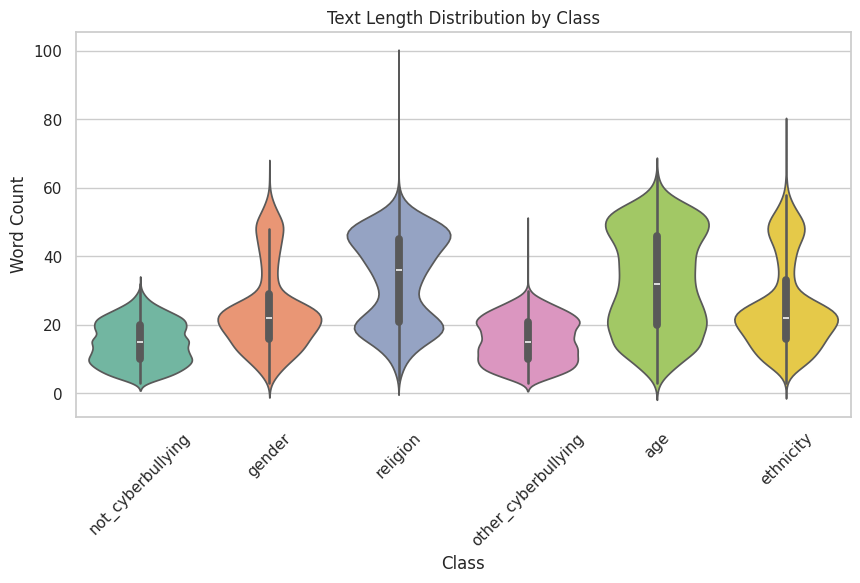

In [ ]:
plt.figure(figsize=(10,5))

sns.violinplot(
    data=df_raw[df_raw["text_len"] <= 100],
    x="cyberbullying_type",
    y="text_len",
    palette="Set2"
)

plt.xticks(rotation=45)
plt.title("Text Length Distribution by Class")
plt.xlabel("Class")
plt.ylabel("Word Count")

# salva figura
plt.savefig(OUTPUT_DIR / "text_length_violinplot_by_class.png", dpi=300, bbox_inches="tight")

plt.show()

# Section 7: Oversampling and loading

For the reasons specified deeply in the report, an oversampling procedure just on the training will be carried out.

Perform oversampling on the training set to balance classes, ensuring each class has 8,000 examples while keeping the text and label arrays aligned.

In [ ]:
# oversampling only on train
# Original non-oversampled data from df_train
# Make copies to ensure we're working with the initial split, not already modified global variables
X_train_initial_clean = df_train["text_clean"].values.copy()
X_train_initial_raw = df_train["text_raw"].values.copy()
y_train_initial = df_train["label_enc"].values.copy()

classes = np.unique(y_train_initial)
sampling_dict = {cls: 8000 for cls in classes}


ros = RandomOverSampler(sampling_strategy=sampling_dict, random_state=42)

# Oversample the indices to apply the same sampling strategy to all related arrays
original_indices = np.arange(len(y_train_initial)).reshape(-1, 1)

# Fit and resample on these indices and the labels.
# The X_res will contain the oversampled indices.
indices_resampled, y_res = ros.fit_resample(original_indices, y_train_initial)

# Now use these resampled indices to create the new X_train, X_train_raw, and y_train
X_train = X_train_initial_clean[indices_resampled.flatten()]
X_train_raw = X_train_initial_raw[indices_resampled.flatten()]
y_train = y_res

print(f"Oversampled X_train length: {len(X_train)}")
print(f"Oversampled X_train_raw length: {len(X_train_raw)}")
print(f"Oversampled y_train length: {len(y_train)}")

Oversampled X_train length: 40000
Oversampled X_train_raw length: 40000
Oversampled y_train length: 40000


#Section 8: Baseline model

Train and evaluate a simple majority-class baseline model using DummyClassifier. This model always predicts the most frequent class in the training set, providing a reference point to compare the performance of more sophisticated classifiers.

In [ ]:
# ── 5.1 Majority Class Baseline ───────────────────────────────────────────────
dummy = DummyClassifier(strategy="most_frequent", random_state=CFG["seed"])
dummy.fit(X_train, y_train)
dummy_preds = dummy.predict(X_test)

evaluate_clf("Majority Baseline", y_test, dummy_preds, label_encoder=le)


  Majority Baseline | TEST
  Accuracy      : 0.2135
  F1 (macro)    : 0.0704
  F1 (weighted) : 0.0751

                   precision    recall  f1-score   support

              age       0.21      1.00      0.35      1183
        ethnicity       0.00      0.00      0.00      1110
           gender       0.00      0.00      0.00      1105
not_cyberbullying       0.00      0.00      0.00       954
         religion       0.00      0.00      0.00      1188

         accuracy                           0.21      5540
        macro avg       0.04      0.20      0.07      5540
     weighted avg       0.05      0.21      0.08      5540



{'accuracy': 0.21353790613718412,
 'f1_macro': 0.07038524468243343,
 'f1_weighted': 0.07514958886220104}

# Section 9: TF-IDF + Logistic Regression

Build TF-IDF features for the dataset, combining word-level n-grams (unigrams and bigrams by default) and optional character-level n-grams. Returns the transformed training, validation, and test sets along with the fitted vectorizers.

In [ ]:


def build_tfidf(word_ngrams=(1, 2), char_ngrams=True, max_features=30000):
    word_vec = TfidfVectorizer(
        analyzer="word",
        ngram_range=word_ngrams,
        max_features=max_features,
        sublinear_tf=True,
        min_df=3,
        max_df=0.95
    )

    X_tr_w = word_vec.fit_transform(X_train)
    X_va_w = word_vec.transform(X_val)
    X_te_w = word_vec.transform(X_test)

    print("Word features:", X_tr_w.shape[1])

    if char_ngrams:
        char_vec = TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 5),
            max_features=10000,
            sublinear_tf=True,
            min_df=3
        )

        X_tr_c = char_vec.fit_transform(X_train)
        X_va_c = char_vec.transform(X_val)
        X_te_c = char_vec.transform(X_test)

        print("Char features:", X_tr_c.shape[1])

        X_tr = hstack([X_tr_w, X_tr_c])
        X_va = hstack([X_va_w, X_va_c])
        X_te = hstack([X_te_w, X_te_c])

        print("Total features:", X_tr.shape[1])

        return X_tr, X_va, X_te, (word_vec, char_vec)

    print("Total features:", X_tr_w.shape[1])
    return X_tr_w, X_va_w, X_te_w, (word_vec,)

Generate TF-IDF features for train, validation, and test sets using the configured word and character n-grams, and display the total number of resulting features.

In [ ]:
X_tr_tfidf, X_va_tfidf, X_te_tfidf, tfidf_vecs = build_tfidf(
    word_ngrams=CFG["tfidf_word_ngrams"],
    char_ngrams=CFG["use_char_ngrams"]
)

print(f"TF-IDF feature dim: {X_tr_tfidf.shape[1]:,}")

Word features: 30000
Char features: 10000
Total features: 40000
TF-IDF feature dim: 40,000


Train and evaluate a Logistic Regression classifier using TF-IDF features. The model applies balanced class weights, optionally performs cross-validation to estimate F1-macro scores, evaluates on validation and test sets, plots the confusion matrix, and saves the trained model for future use.

[LogReg CV] F1-macro: 0.9536 ± 0.0013

  TF-IDF + LogReg | VAL
  Accuracy      : 0.9312
  F1 (macro)    : 0.9278
  F1 (weighted) : 0.9318

                   precision    recall  f1-score   support

              age       0.97      0.98      0.98      1183
        ethnicity       0.99      0.98      0.98      1110
           gender       0.93      0.87      0.90      1104
not_cyberbullying       0.79      0.86      0.82       954
         religion       0.96      0.95      0.96      1189

         accuracy                           0.93      5540
        macro avg       0.93      0.93      0.93      5540
     weighted avg       0.93      0.93      0.93      5540


  TF-IDF + LogReg | TEST
  Accuracy      : 0.9319
  F1 (macro)    : 0.9290
  F1 (weighted) : 0.9329

                   precision    recall  f1-score   support

              age       0.97      0.97      0.97      1183
        ethnicity       0.99      0.98      0.99      1110
           gender       0.93      0.88      0.9

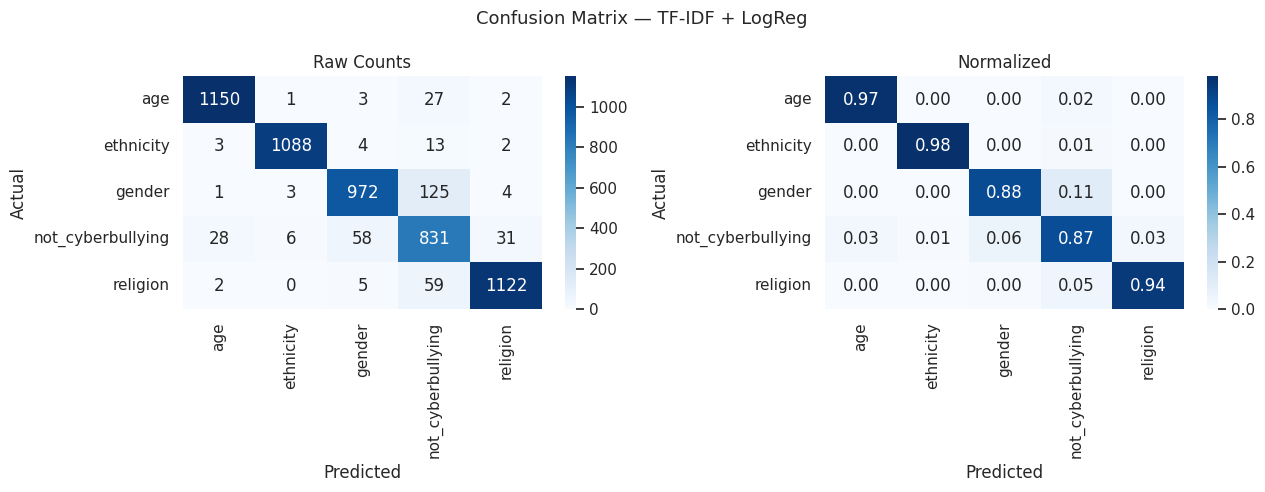

['models/logreg.pkl']

In [ ]:
# ── 5.3 TF-IDF + Logistic Regression ─────────────────────────────────────────

CFG["class_weight"] = "balanced"
CFG["use_cv"] = True
CFG["cv_folds"] = 5
CFG["output_dir"] = Path("outputs/")
CFG["model_dir"] = Path("models/")
CFG["output_paths"] = {
    "plots_comparison": Path("outputs/"),
    "plots_confusion":  Path("outputs/"),
    "plots_history":    Path("outputs/"),
    "metrics":          Path("outputs/"),
}

logreg = LogisticRegression(
    max_iter=1000, C=1.0,
    class_weight=CFG["class_weight"],
    solver="saga",
    random_state=CFG["seed"]
)

if CFG["use_cv"]:
    cv_scores = cross_val_score(
        logreg, X_tr_tfidf, y_train,
        cv=cv, scoring="f1_macro", n_jobs=-1
    )
    print(f"[LogReg CV] F1-macro: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

logreg.fit(X_tr_tfidf, y_train)

evaluate_clf("TF-IDF + LogReg", y_val,
             logreg.predict(X_va_tfidf), label_encoder=le, split="val")
evaluate_clf("TF-IDF + LogReg", y_test,
             logreg.predict(X_te_tfidf),
             logreg.predict_proba(X_te_tfidf), label_encoder=le)
plot_confusion_matrix_clf(y_test, logreg.predict(X_te_tfidf), "TF-IDF + LogReg", le)



plt.savefig(OUTPUT_DIR / "confusion_matrix_logreg.png", dpi=300, bbox_inches="tight")
plt.close()
joblib.dump(logreg, CFG["model_dir"] / "logreg.pkl")

In [ ]:
print(xgboost.__version__)

3.2.0


# Section 10: TF-IDF + XGBoost

Train and evaluate an XGBoost classifier using TF-IDF features. The model is GPU-ready, fits on the training set, evaluates on validation and test sets, generates metrics and a confusion matrix, and saves the trained model for later use.

[0]	validation_0-mlogloss:1.42025
[1]	validation_0-mlogloss:1.27177
[2]	validation_0-mlogloss:1.15116
[3]	validation_0-mlogloss:1.05056
[4]	validation_0-mlogloss:0.96589
[5]	validation_0-mlogloss:0.89092
[6]	validation_0-mlogloss:0.82630
[7]	validation_0-mlogloss:0.77013
[8]	validation_0-mlogloss:0.71895
[9]	validation_0-mlogloss:0.67380
[10]	validation_0-mlogloss:0.63375
[11]	validation_0-mlogloss:0.59860
[12]	validation_0-mlogloss:0.56628
[13]	validation_0-mlogloss:0.53740
[14]	validation_0-mlogloss:0.51123
[15]	validation_0-mlogloss:0.48757
[16]	validation_0-mlogloss:0.46599
[17]	validation_0-mlogloss:0.44641
[18]	validation_0-mlogloss:0.42834
[19]	validation_0-mlogloss:0.41231
[20]	validation_0-mlogloss:0.39739
[21]	validation_0-mlogloss:0.38363
[22]	validation_0-mlogloss:0.37170
[23]	validation_0-mlogloss:0.36030
[24]	validation_0-mlogloss:0.34968
[25]	validation_0-mlogloss:0.33966
[26]	validation_0-mlogloss:0.33050
[27]	validation_0-mlogloss:0.32223
[28]	validation_0-mlogloss:0.3

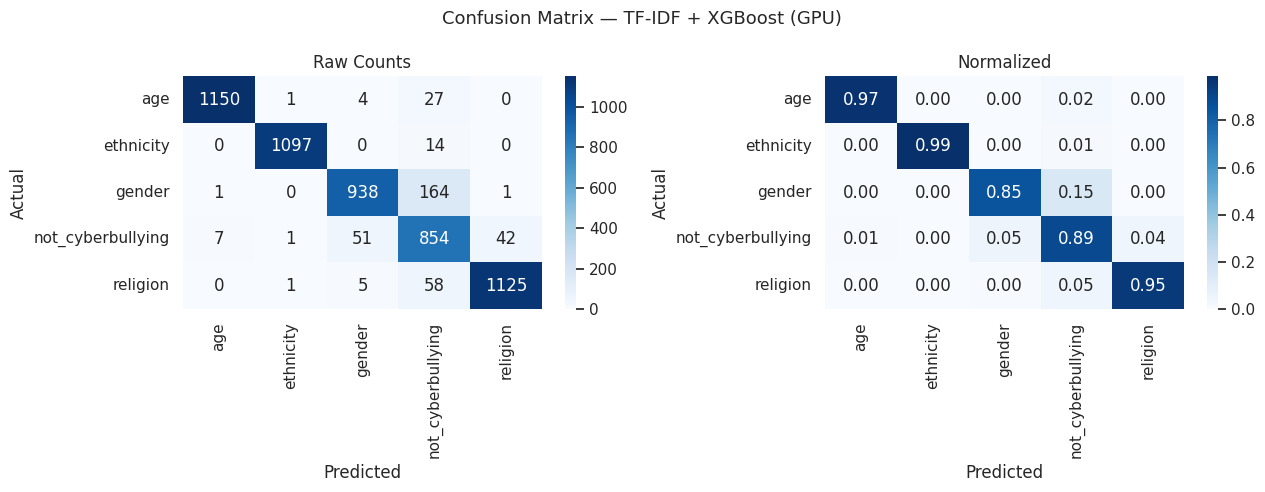

['models/xgboost_gpu.pkl']

In [ ]:
# ── 5.4 TF-IDF + XGBoost (GPU Ready, no CV) ─────────────────────────────
xgb = XGBClassifier(
    n_estimators=250,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    eval_metric="mlogloss",
    random_state=CFG["seed"],
    verbosity=1
)


xgb.fit(
    X_tr_tfidf, y_train,
    eval_set=[(X_va_tfidf, y_val)],

    verbose=True
)


xgb_val_preds = xgb.predict(X_va_tfidf)
xgb_test_preds = xgb.predict(X_te_tfidf)


evaluate_clf("TF-IDF + XGBoost (GPU)", y_val, xgb_val_preds, label_encoder=le, split="val")
evaluate_clf("TF-IDF + XGBoost (GPU)", y_test, xgb_test_preds, xgb.predict_proba(X_te_tfidf), label_encoder=le)
plot_confusion_matrix_clf(y_test, xgb_test_preds, "TF-IDF + XGBoost (GPU)", le)

joblib.dump(xgb, CFG["model_dir"] / "xgboost_gpu.pkl")

# Section 11: Utilities

Build a vocabulary from the training set for deep learning models, limiting it to the top 30,000 tokens and defining special padding (<PAD>) and unknown (<UNK>) tokens.

In [ ]:
# ── 6.1 Vocabulary Builder ────────────────────────────────────────────────────

CFG["vocab_size"] = 30_000
CFG["pad_token"] = "<PAD>"
CFG["unk_token"] = "<UNK>"


vocab = build_vocab(
    X_train,
    max_vocab=CFG["vocab_size"],
    pad_token=CFG["pad_token"],
    unk_token=CFG["unk_token"]
)
print(f"Vocabulary size: {len(vocab):,}")

Vocabulary size: 28,749


Create an embedding matrix for the vocabulary using pre-trained word vectors (GloVe), mapping each token to a 100-dimensional vector for use in deep learning models.

In [ ]:
# ── 6.2 Embedding Matrix ──────────────────────────────────────────────────────

CFG["embedding_model"] = "glove-wiki-gigaword-100" # or "fasttext-wiki-news-subwords-300"
CFG["embedding_dim"] = 100

embedding_matrix = load_embedding_matrix(
    vocab, CFG["embedding_model"], CFG["embedding_dim"]
)
print(f"Embedding matrix shape: {embedding_matrix.shape}")

Loading glove-wiki-gigaword-100 ...
[==================================================] 100.0% 128.1/128.1MB downloaded
Coverage: 49.5%  (hits=14242, misses=14507)
Embedding matrix shape: (28749, 100)


Generate a matrix where each word in the vocabulary is represented by its 100-dimensional GloVe embedding, providing pretrained semantic representations for deep learning models.

In [ ]:
# ── 6.3 Text → Padded Token-ID Sequences ─────────────────────────────────────


CFG["max_seq_len"] = 128

seq_train = texts_to_sequences(X_train, vocab, CFG["max_seq_len"])
seq_val   = texts_to_sequences(X_val,   vocab, CFG["max_seq_len"])
seq_test  = texts_to_sequences(X_test,  vocab, CFG["max_seq_len"])

print(f"seq_train: {seq_train.shape} | seq_val: {seq_val.shape} | seq_test: {seq_test.shape}")

seq_train: (40000, 128) | seq_val: (5540, 128) | seq_test: (5540, 128)


Create PyTorch Dataset objects and DataLoaders for training, validation, and test sets, enabling efficient batching and shuffling for deep learning models.

In [ ]:
# ── 6.4 PyTorch Dataset & DataLoaders ────────────────────────────────────────
CFG["dl_batch_size"] = 64

loader_train, loader_val, loader_test = make_loaders(
    seq_train, y_train, seq_val, y_val, seq_test, y_test,
    batch_size=CFG["dl_batch_size"]
)
print("DataLoaders ready.")

DataLoaders ready.


# Section 12: Text CNN


Set up and train a multi-layer perceptron (MLP) using the pre-trained GloVe embeddings. The configuration specifies the number of classes, dropout rate, learning rate, number of epochs, and device (CPU, CUDA, or MPS). After initializing the model and setting a random seed for reproducibility, the MLP is trained using the training and validation DataLoaders. Training history is plotted to visualize loss and accuracy over epochs. Finally, predictions are made on the test set, performance metrics are evaluated, and a confusion matrix is generated to analyze class-level performance.

MLP params: 2,900,341
Resumed from models/glove_mlp/checkpoints/last.pt (epoch=5, best_f1=0.8863)
Epoch   6/20 | tr_loss=0.0196 | va_loss=0.4717 | val_f1=0.8733 | 0.7s
Early stopping triggered at epoch 6.
Restored best checkpoint | val_f1=0.8863 | path=models/glove_mlp/checkpoints/best.pt
Training complete.


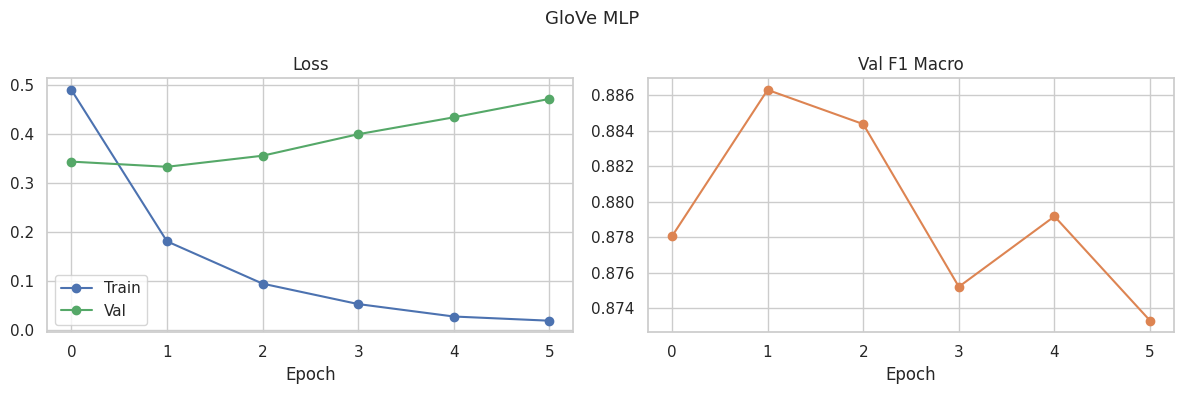


  GloVe MLP | TEST
  Accuracy      : 0.8950
  F1 (macro)    : 0.8875
  F1 (weighted) : 0.8936

                   precision    recall  f1-score   support

              age       0.95      0.96      0.95      1182
        ethnicity       0.96      0.96      0.96      1111
           gender       0.88      0.86      0.87      1104
not_cyberbullying       0.75      0.70      0.72       955
         religion       0.91      0.96      0.93      1189

         accuracy                           0.89      5541
        macro avg       0.89      0.89      0.89      5541
     weighted avg       0.89      0.89      0.89      5541



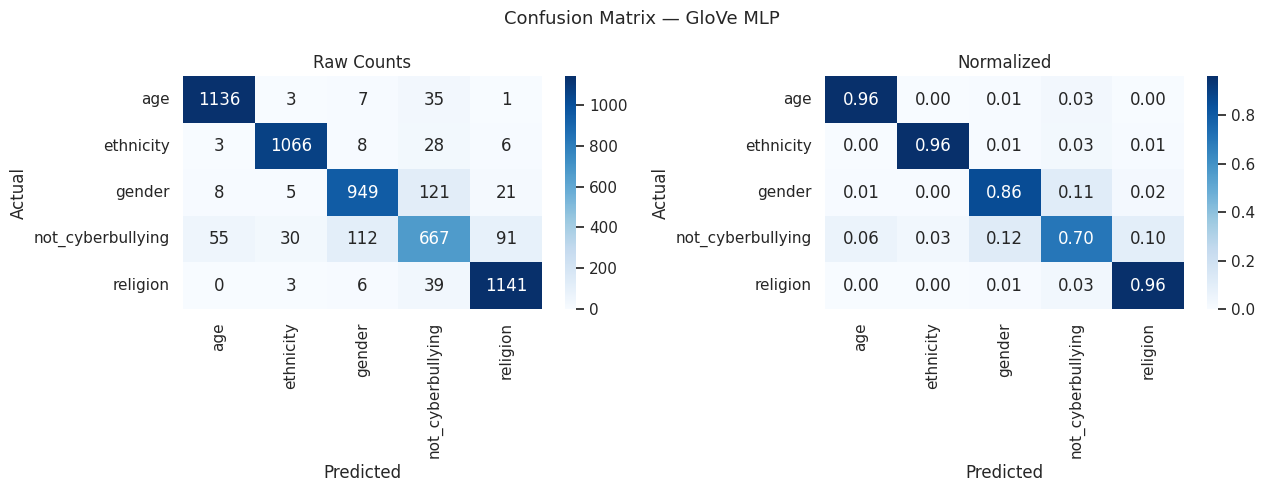

In [ ]:
CFG["num_labels"] = len(le.classes_)
CFG["dropout"] = 0.3
CFG["dl_epochs"] = 20
CFG["dl_lr"] = 1e-3
CFG["dl_patience"] = 3
CFG["device"] = (
    "mps"  if torch.backends.mps.is_available() and torch.backends.mps.is_built()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
# Restore Path objects for directories
CFG["output_dir"] = Path("outputs/")
CFG["model_dir"] = Path("models/")
CFG["log_dir"] = Path("logs/")

set_seed(CFG["seed"])
mlp_model = EmbeddingMLP(
    embedding_matrix=embedding_matrix,
    num_classes=CFG["num_labels"],
    hidden_dim=256,
    dropout=CFG["dropout"]
)
print(f"MLP params: {sum(p.numel() for p in mlp_model.parameters()):,}")

mlp_history = train_model(
    mlp_model, loader_train, loader_val,
    model_name="GloVe MLP",
    epochs=CFG["dl_epochs"], lr=CFG["dl_lr"],
    patience=CFG["dl_patience"], device=CFG["device"]
)
plot_history(mlp_history, "GloVe MLP")

mlp_preds = predict(mlp_model, loader_test, CFG["device"])
evaluate_clf("GloVe MLP", y_test, mlp_preds, label_encoder=le)
plot_confusion_matrix_clf(y_test, mlp_preds, "GloVe MLP", le)

# Section 13: BiLSTM + Attention

Set up and train a BiLSTM model with attention using pre-trained GloVe embeddings. The configuration specifies hidden dimensions, number of LSTM layers, dropout rate, learning rate, number of epochs, patience for early stopping, and the computation device (CPU, CUDA, or MPS). After initializing the model and ensuring reproducibility with a fixed seed, the network is trained using the training and validation DataLoaders. Training history is visualized to monitor loss and accuracy. Finally, predictions are made on the test set, classification performance is evaluated with metrics, and a confusion matrix is plotted to analyze how well the model distinguishes each class.

BiLSTM params: 3,505,525
Epoch   1/20 | tr_loss=0.1931 | va_loss=0.2856 | val_f1=0.8985 | 3.0s ✓  <-- new best
Epoch   2/20 | tr_loss=0.0869 | va_loss=0.3128 | val_f1=0.8996 | 2.8s ✓  <-- new best
Epoch   3/20 | tr_loss=0.0622 | va_loss=0.3450 | val_f1=0.8937 | 2.8s
Epoch   4/20 | tr_loss=0.0471 | va_loss=0.3628 | val_f1=0.8913 | 2.8s
Epoch   5/20 | tr_loss=0.0311 | va_loss=0.3953 | val_f1=0.8955 | 2.8s
Early stopping triggered at epoch 5.
Restored best checkpoint | val_f1=0.8996 | path=models/glove_bilstm_att/checkpoints/best.pt
Training complete.


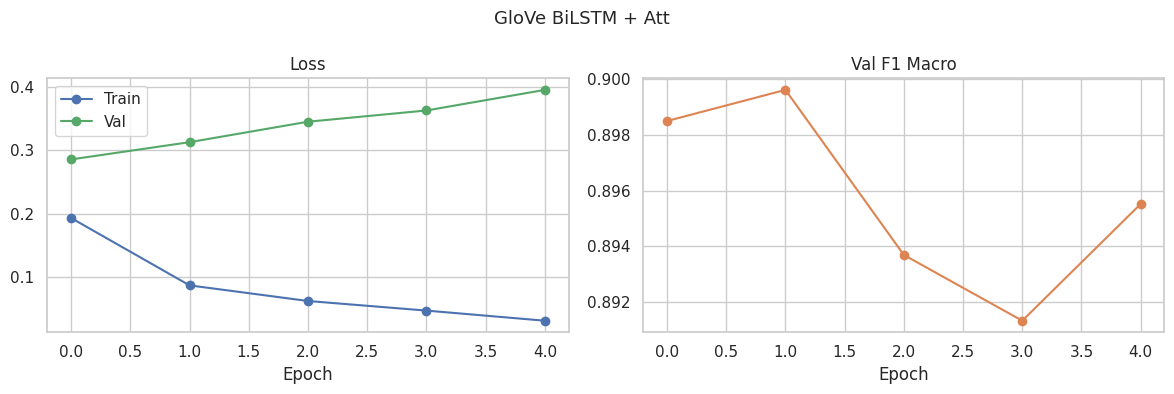


  GloVe BiLSTM + Att | TEST
  Accuracy      : 0.9058
  F1 (macro)    : 0.8987
  F1 (weighted) : 0.9042

                   precision    recall  f1-score   support

              age       0.94      0.98      0.96      1182
        ethnicity       0.96      0.98      0.97      1111
           gender       0.90      0.85      0.87      1104
not_cyberbullying       0.78      0.73      0.75       955
         religion       0.93      0.95      0.94      1189

         accuracy                           0.91      5541
        macro avg       0.90      0.90      0.90      5541
     weighted avg       0.90      0.91      0.90      5541



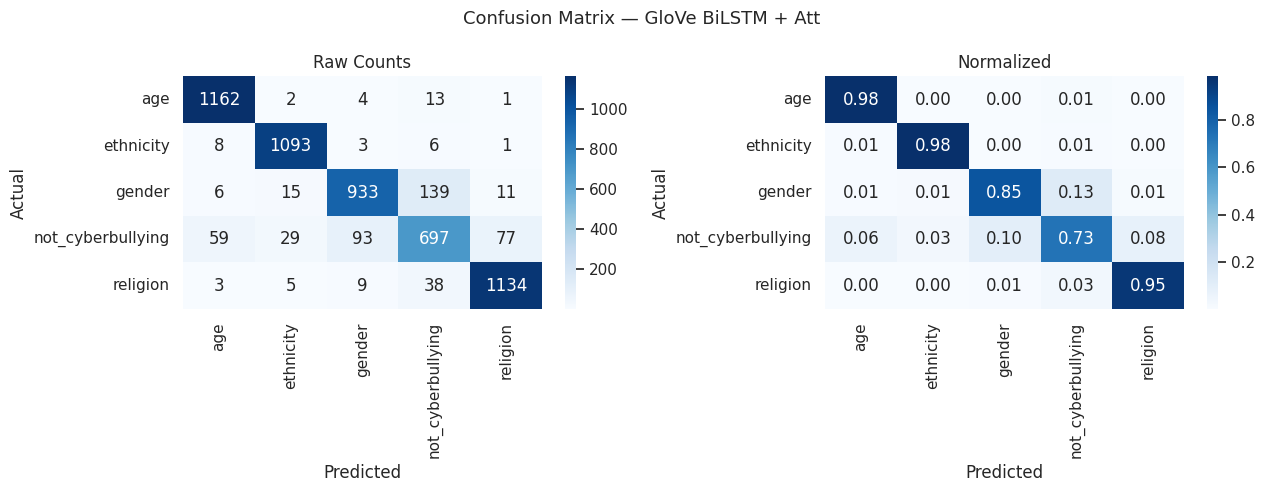

In [ ]:
# ── 9.3 Train BiLSTM + Attention ──────────────────────────────────────────────

CFG["lstm_hidden_dim"] = 128
CFG["lstm_num_layers"] = 2
CFG["dropout"] = 0.3
CFG["dl_epochs"] = 20
CFG["dl_lr"] = 1e-3
CFG["dl_patience"] = 3
CFG["device"] = (
    "mps"  if torch.backends.mps.is_available() and torch.backends.mps.is_built()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
# Restore Path objects for directories
CFG["output_dir"] = Path("outputs/")
CFG["model_dir"] = Path("models/")
CFG["log_dir"] = Path("logs/")

set_seed(CFG["seed"])

atentos_model = BiLSTMAttention(
    embedding_matrix=embedding_matrix,
    num_classes=CFG["num_labels"],
    hidden_dim=CFG["lstm_hidden_dim"],
    num_layers=CFG["lstm_num_layers"],
    dropout=CFG["dropout"]
)
print(f"BiLSTM params: {sum(p.numel() for p in atentos_model.parameters()):,}")

att_history = train_model(
    atentos_model, loader_train, loader_val,
    model_name="GloVe BiLSTM + Att",
    epochs=CFG["dl_epochs"], lr=CFG["dl_lr"],
    patience=CFG["dl_patience"], device=CFG["device"]
)
plot_history(att_history, "GloVe BiLSTM + Att")

att_preds = predict(atentos_model, loader_test, CFG["device"])
evaluate_clf("GloVe BiLSTM + Att", y_test, att_preds, label_encoder=le)
plot_confusion_matrix_clf(y_test, att_preds, "GloVe BiLSTM + Att", le)

# Section 14: GloVe CNN

Set up and train a TextCNN model using pre-trained GloVe embeddings. The configuration defines the number of convolutional filters, kernel sizes, dropout rate, learning rate, number of epochs, early stopping patience, and the computation device (CPU, CUDA, or MPS). After initializing the model and fixing the random seed for reproducibility, the network is trained on the training and validation sets. Training history is plotted to track performance over epochs. Finally, predictions are made on the test set, evaluation metrics are calculated, and a confusion matrix is generated to assess class-level performance.

TextCNN params: 2,990,709
Epoch   1/20 | tr_loss=0.1807 | va_loss=0.2990 | val_f1=0.8964 | 1.4s ✓  <-- new best
Epoch   2/20 | tr_loss=0.0602 | va_loss=0.3397 | val_f1=0.8919 | 0.9s
Epoch   3/20 | tr_loss=0.0290 | va_loss=0.3916 | val_f1=0.8907 | 0.9s
Epoch   4/20 | tr_loss=0.0131 | va_loss=0.4275 | val_f1=0.8910 | 0.9s
Early stopping triggered at epoch 4.
Restored best checkpoint | val_f1=0.8964 | path=models/glove_cnn/checkpoints/best.pt
Training complete.


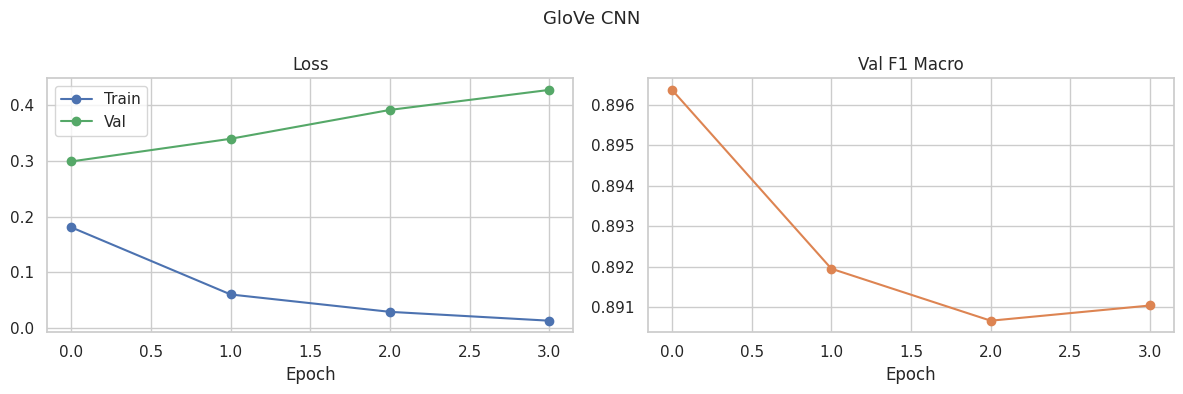


  GloVe CNN | TEST
  Accuracy      : 0.9013
  F1 (macro)    : 0.8917
  F1 (weighted) : 0.8980

                   precision    recall  f1-score   support

              age       0.95      0.98      0.96      1182
        ethnicity       0.96      0.98      0.97      1111
           gender       0.86      0.88      0.87      1104
not_cyberbullying       0.80      0.66      0.72       955
         religion       0.90      0.97      0.93      1189

         accuracy                           0.90      5541
        macro avg       0.89      0.89      0.89      5541
     weighted avg       0.90      0.90      0.90      5541



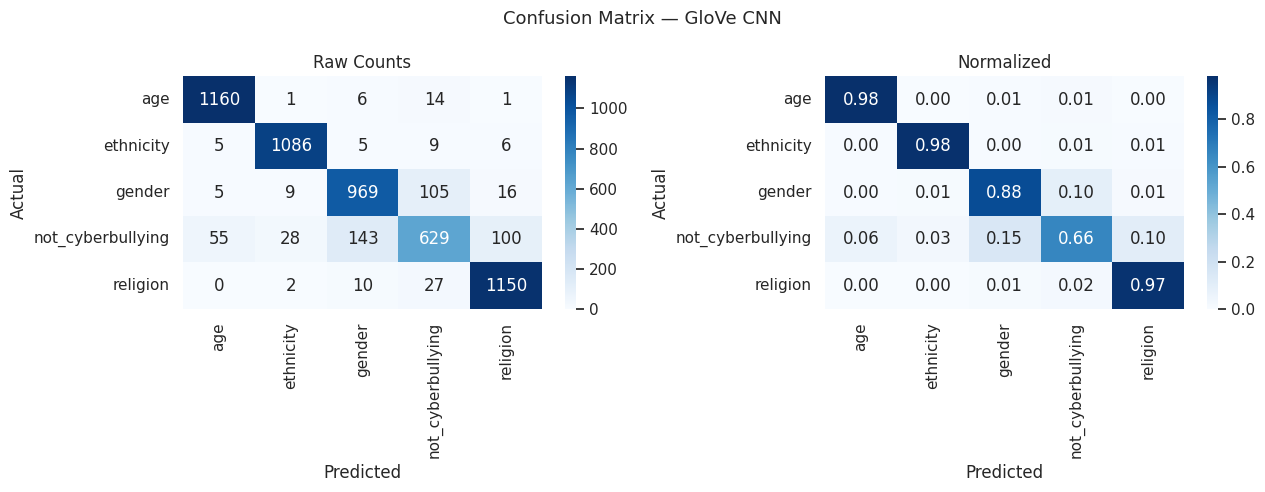

In [ ]:
set_seed(42)

# ── 8.4 Train TextCNN ────────────────────────────────────────────────────────
CFG["cnn_num_filters"] = 128
CFG["cnn_kernel_sizes"] = [2, 3, 4]
CFG["dropout"] = 0.3
CFG["dl_epochs"] = 20
CFG["dl_lr"] = 1e-3
CFG["dl_patience"] = 3
CFG["device"] = (
    "mps"  if torch.backends.mps.is_available() and torch.backends.mps.is_built()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
# Restore Path objects for directories
CFG["output_dir"] = Path("outputs/")
CFG["model_dir"] = Path("models/")
CFG["log_dir"] = Path("logs/")

set_seed(CFG["seed"])
cnn_model = TextCNN(
    embedding_matrix=embedding_matrix,
    num_classes=CFG["num_labels"],
    num_filters=CFG["cnn_num_filters"],
    kernel_sizes=CFG["cnn_kernel_sizes"],
    dropout=CFG["dropout"]
)
print(f"TextCNN params: {sum(p.numel() for p in cnn_model.parameters()):,}")

cnn_history = train_model(
    cnn_model, loader_train, loader_val,
    model_name="GloVe CNN",
    epochs=CFG["dl_epochs"], lr=CFG["dl_lr"],
    patience=CFG["dl_patience"], device=CFG["device"]
)
plot_history(cnn_history, "GloVe CNN")

cnn_preds = predict(cnn_model, loader_test, CFG["device"])
evaluate_clf("GloVe CNN", y_test, cnn_preds, label_encoder=le)
plot_confusion_matrix_clf(y_test, cnn_preds, "GloVe CNN", le)

# Section 15:  GloVe BiLSTM

Set up and train a BiLSTM model (without explicit attention) using pre-trained GloVe embeddings. The model configuration includes hidden dimensions, number of layers, dropout, learning rate, number of epochs, and computation device. After initializing the model and ensuring reproducibility with a fixed seed, training is performed on the training and validation sets. Training history is plotted to monitor performance, and the trained model is evaluated on the test set with classification metrics and a confusion matrix to analyze per-class performance.

BiLSTM params: 3,505,525
Epoch   1/20 | tr_loss=0.1931 | va_loss=0.2856 | val_f1=0.8985 | 2.8s ✓  <-- new best
Epoch   2/20 | tr_loss=0.0869 | va_loss=0.3128 | val_f1=0.8996 | 2.8s ✓  <-- new best
Epoch   3/20 | tr_loss=0.0622 | va_loss=0.3450 | val_f1=0.8937 | 2.8s
Epoch   4/20 | tr_loss=0.0471 | va_loss=0.3628 | val_f1=0.8913 | 2.8s
Epoch   5/20 | tr_loss=0.0311 | va_loss=0.3953 | val_f1=0.8955 | 2.8s
Early stopping triggered at epoch 5.
Restored best checkpoint | val_f1=0.8996 | path=models/glove_bilstm/checkpoints/best.pt
Training complete.


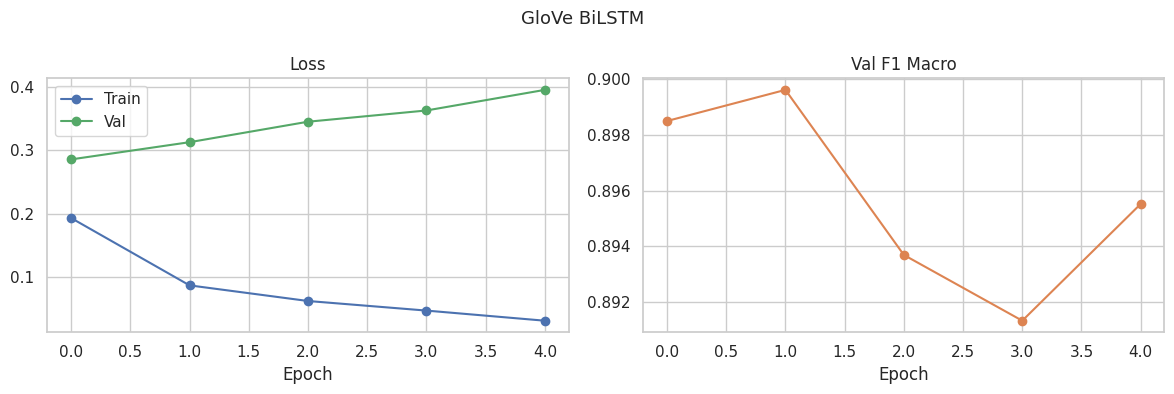


  GloVe BiLSTM | TEST
  Accuracy      : 0.9058
  F1 (macro)    : 0.8987
  F1 (weighted) : 0.9042

                   precision    recall  f1-score   support

              age       0.94      0.98      0.96      1182
        ethnicity       0.96      0.98      0.97      1111
           gender       0.90      0.85      0.87      1104
not_cyberbullying       0.78      0.73      0.75       955
         religion       0.93      0.95      0.94      1189

         accuracy                           0.91      5541
        macro avg       0.90      0.90      0.90      5541
     weighted avg       0.90      0.91      0.90      5541



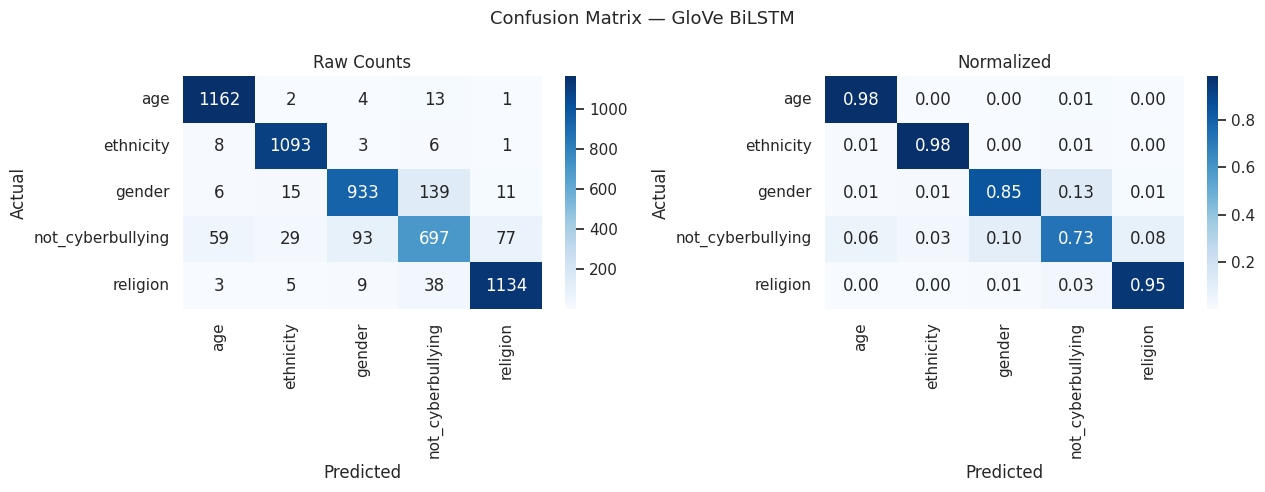

In [ ]:
# ── 9.3 Train BiLSTM ──────────────────────────────────────────────────────────
set_seed(CFG["seed"])
bilstm_model = BiLSTMAttention(
    embedding_matrix=embedding_matrix,
    num_classes=CFG["num_labels"],
    hidden_dim=CFG["lstm_hidden_dim"],
    num_layers=CFG["lstm_num_layers"],
    dropout=CFG["dropout"]
)
print(f"BiLSTM params: {sum(p.numel() for p in bilstm_model.parameters()):,}")

lstm_history = train_model(
    bilstm_model, loader_train, loader_val,
    model_name="GloVe BiLSTM",
    epochs=CFG["dl_epochs"], lr=CFG["dl_lr"],
    patience=CFG["dl_patience"], device=CFG["device"]
)
plot_history(lstm_history, "GloVe BiLSTM")

bilstm_preds = predict(bilstm_model, loader_test, CFG["device"])
evaluate_clf("GloVe BiLSTM", y_test, bilstm_preds, label_encoder=le)
plot_confusion_matrix_clf(y_test, bilstm_preds, "GloVe BiLSTM", le)

# Section 16: BERT

Initialize a Hugging Face tokenizer (BERT) and create tokenized datasets for training, validation, and test sets, truncating or padding sequences to a maximum length of 256 tokens.

In [ ]:
# ── 10.3 Tokeniser & Datasets ─────────────────────────────────────────────────
CFG["trf_model"] = "bert-base-uncased"
CFG["max_len"] = 256

trf_tokenizer = AutoTokenizer.from_pretrained(CFG["trf_model"])

trf_ds_train = HFTextDataset(X_train_raw, y_train, trf_tokenizer, CFG["max_len"])
trf_ds_val   = HFTextDataset(X_val_raw,   y_val,   trf_tokenizer, CFG["max_len"])
trf_ds_test  = HFTextDataset(X_test_raw,  y_test,  trf_tokenizer, CFG["max_len"])

print(f"Train HF dataset: {len(trf_ds_train)} | "
      f"Val: {len(trf_ds_val)} | Test: {len(trf_ds_test)}")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train HF dataset: 40000 | Val: 5540 | Test: 5540


Set up and train a transformer-based classifier (BERT) for cyberbullying detection. The configuration defines batch size, learning rate, number of epochs, and maximum sequence length. The Hugging Face tokenizer is used to convert raw text into token IDs, creating training, validation, and test datasets. The model is initialized for single-label classification with the appropriate number of classes. TrainingArguments specify evaluation and saving strategies, warmup steps, weight decay, logging to TensorBoard, mixed-precision training if CUDA is available, and a random seed for reproducibility. An early stopping callback is included to halt training if validation performance does not improve. Finally, a Trainer object handles the training loop, optionally resuming from the last checkpoint, and trains the model while computing metrics at each evaluation step.

In [ ]:
# ── 10.4 Model + Trainer ────────────────────────

CFG["batch_size"] = 16
CFG["epochs"] = 5
CFG["lr"] = 2e-5
# Restore Path objects for directories
CFG["output_dir"] = Path("outputs/")
CFG["model_dir"] = Path("models/")
CFG["log_dir"] = Path("logs/")

out_dir = CFG["model_dir"] / "transformer"
out_dir.mkdir(parents=True, exist_ok=True)

trf_model = AutoModelForSequenceClassification.from_pretrained(
    CFG["trf_model"],
    num_labels=CFG["num_labels"],
    problem_type="single_label_classification",
    from_tf=False,
)

training_args = TrainingArguments(
    output_dir=str(out_dir),
    num_train_epochs=CFG["epochs"],
    per_device_train_batch_size=CFG["batch_size"],
    per_device_eval_batch_size=CFG["batch_size"],
    learning_rate=CFG["lr"],
    warmup_steps=int(0.06 * len(X_train_raw) / CFG["batch_size"] * CFG["epochs"]), # Use warmup_steps instead of warmup_ratio
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,

    logging_dir=str(CFG["log_dir"] / "tensorboard"), # Use TENSORBOARD_LOGGING_DIR compatible path
    logging_strategy="epoch",
    report_to="tensorboard",

    fp16=torch.cuda.is_available(),
    seed=CFG["seed"],
)

# Recreate datasets with updated X_train_raw and y_train after oversampling
trf_ds_train = HFTextDataset(X_train_raw, y_train, trf_tokenizer, CFG["max_len"])
trf_ds_val   = HFTextDataset(X_val_raw,   y_val,   trf_tokenizer, CFG["max_len"])
trf_ds_test  = HFTextDataset(X_test_raw,  y_test,  trf_tokenizer, CFG["max_len"])

print(f"Re-created Train HF dataset: {len(trf_ds_train)} | "
      f"Val: {len(trf_ds_val)} | Test: {len(trf_ds_test)}")

trainer = Trainer(
    model=trf_model,
    args=training_args,
    train_dataset=trf_ds_train,
    eval_dataset=trf_ds_val,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

last_ckpt = get_last_checkpoint(str(out_dir))
print("Last checkpoint:", last_ckpt)

trainer.train(resume_from_checkpoint=last_ckpt if last_ckpt is not None else None)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will 

Re-created Train HF dataset: 40000 | Val: 5541 | Test: 5541
Last checkpoint: None


Epoch,Training Loss,Validation Loss,F1 Macro,Accuracy
1,0.354808,0.244865,0.927507,0.930337
2,0.105767,0.270295,0.931384,0.933947
3,0.039346,0.393331,0.928639,0.932323
4,0.016137,0.416943,0.930993,0.934849


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=10000, training_loss=0.12901439590454103, metrics={'train_runtime': 305.0126, 'train_samples_per_second': 655.711, 'train_steps_per_second': 40.982, 'total_flos': 2.104945139712e+16, 'train_loss': 0.12901439590454103, 'epoch': 4.0})

Save the Hugging Face Trainer’s logging history to both JSON and CSV files for future reference, and display the last 20 entries to inspect recent training and evaluation metrics.

In [ ]:
hist = trainer.state.log_history

ts = datetime.now().strftime("%Y%m%d_%H%M%S")
json_path = CFG["log_dir"] / f"trainer_log_history_{ts}.json"
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(hist, f, ensure_ascii=False, indent=2)

df_hist = pd.DataFrame(hist)
csv_path = CFG["log_dir"] / f"trainer_log_history_{ts}.csv"
df_hist.to_csv(csv_path, index=False)

print("Saved:", json_path, csv_path)
display(df_hist.tail(20))

Saved: logs/trainer_log_history_20260316_134913.json logs/trainer_log_history_20260316_134913.csv


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_f1_macro,eval_accuracy,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.354808,3.993441,0.000017,1.0,2500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,1.0,2500,0.244865,0.927507,0.930337,3.3899,1634.584,102.364,NaN,NaN,NaN,NaN,NaN
2,0.105767,0.059244,0.000013,2.0,5000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,2.0,5000,0.270295,0.931384,0.933947,3.3814,1638.681,102.621,NaN,NaN,NaN,NaN,NaN
4,0.039346,1.034506,0.000009,3.0,7500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,3.0,7500,0.393331,0.928639,0.932323,3.3774,1640.620,102.742,NaN,NaN,NaN,NaN,NaN
6,0.016137,0.076713,0.000004,4.0,10000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,4.0,10000,0.416943,0.930993,0.934849,3.3854,1636.745,102.500,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,4.0,10000,NaN,NaN,NaN,NaN,NaN,NaN,305.0126,655.711,40.982,2.104945e+16,0.129014


Evaluate the fine-tuned BERT transformer on the validation and test sets by generating predictions, computing classification metrics, and plotting a confusion matrix. Finally, save the trained model and tokenizer for future use.


  BERT Fine-tune | VAL
  Accuracy      : 0.9338
  F1 (macro)    : 0.9312
  F1 (weighted) : 0.9349

                   precision    recall  f1-score   support

              age       0.99      0.98      0.99      1181
        ethnicity       0.98      0.98      0.98      1112
           gender       0.94      0.87      0.90      1104
not_cyberbullying       0.78      0.89      0.83       955
         religion       0.97      0.94      0.95      1189

         accuracy                           0.93      5541
        macro avg       0.93      0.93      0.93      5541
     weighted avg       0.94      0.93      0.93      5541


  BERT Fine-tune | TEST
  Accuracy      : 0.9403
  F1 (macro)    : 0.9375
  F1 (weighted) : 0.9410

                   precision    recall  f1-score   support

              age       0.99      0.98      0.99      1182
        ethnicity       0.99      0.99      0.99      1111
           gender       0.94      0.89      0.91      1104
not_cyberbullying       0.81

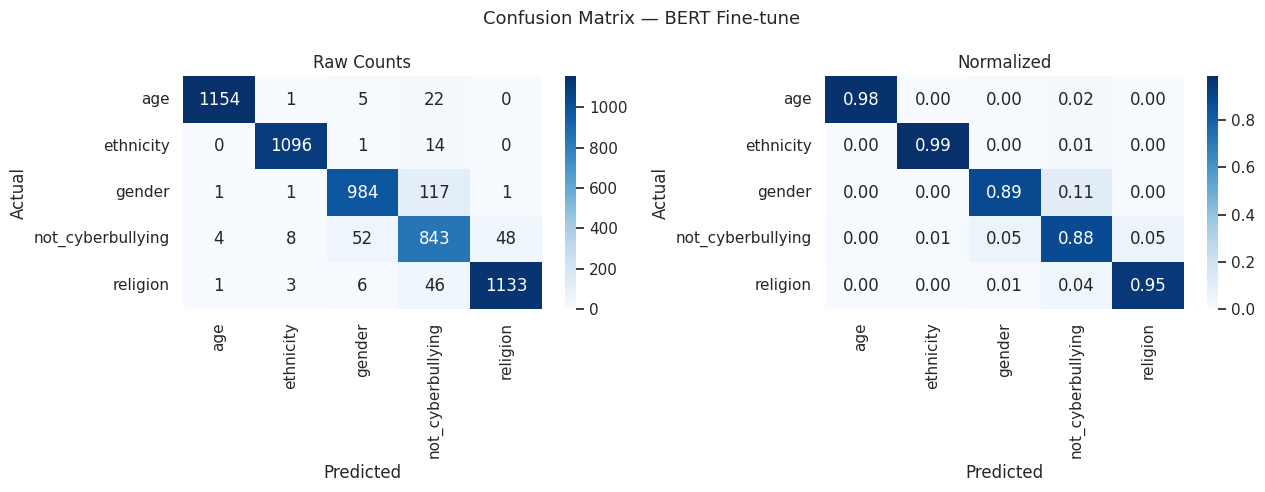

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Transformer model saved.


In [ ]:
# ── 10.5 Evaluate Transformer ─────────────────────────────────────────────────
trf_val_output  = trainer.predict(trf_ds_val)
trf_test_output = trainer.predict(trf_ds_test)

trf_val_preds  = np.argmax(trf_val_output.predictions,  axis=1)
trf_test_preds = np.argmax(trf_test_output.predictions, axis=1)

evaluate_clf("BERT Fine-tune", y_val,  trf_val_preds,  label_encoder=le, split="val")
evaluate_clf("BERT Fine-tune", y_test, trf_test_preds, label_encoder=le)
plot_confusion_matrix_clf(y_test, trf_test_preds, "BERT Fine-tune", le)

# Save fine-tuned model & tokenizer
trainer.save_model(str(CFG["model_dir"] / "transformer_best"))
trf_tokenizer.save_pretrained(str(CFG["model_dir"] / "transformer_best"))
print("Transformer model saved.")

# Section 17: Results

Display a summary table comparing the performance of all trained models across metrics and datasets.

In [ ]:
print_results_table()


Model                                              accuracy      f1_macro   f1_weighted
Majority Baseline | test                             0.2133        0.0703        0.0750
TF-IDF + LogReg | val                                0.9240        0.9207        0.9248
TF-IDF + LogReg | test                               0.9284        0.9246        0.9288
TF-IDF + XGBoost (GPU) | val                         0.9284        0.9260        0.9302
TF-IDF + XGBoost (GPU) | test                        0.9320        0.9293        0.9334
GloVe MLP | test                                     0.8950        0.8875        0.8936
GloVe BiLSTM + Att | test                            0.9058        0.8987        0.9042
GloVe CNN | test                                     0.9013        0.8917        0.8980
GloVe BiLSTM | test                                  0.9058        0.8987        0.9042
BERT Fine-tune | val                                 0.9338        0.9312        0.9349
BERT Fine-tune | test          

Summary table shows that all models outperform the majority-class baseline, with transformer-based BERT achieving the highest accuracy and F1 scores on both validation and test sets. Traditional ML models like TF-IDF + XGBoost also perform very well, while deep learning models using GloVe embeddings achieve slightly lower but competitive results.

In [ ]:
# ── 11.2 Results as DataFrame ─────────────────────────────────────────────────
df_results = (
    pd.DataFrame(RESULTS)
    .T
    .rename_axis("Model | Split")
    .sort_values("f1_macro", ascending=False)
)
display(df_results.round(4))

df_results.to_csv(CFG["output_dir"] / f"results_{CFG['task']}.csv")
print("Results saved.")

,accuracy,f1_macro,f1_weighted
Model | Split,,,
BERT Fine-tune | test,0.9403,0.9375,0.9410
BERT Fine-tune | val,0.9338,0.9312,0.9349
TF-IDF + XGBoost (GPU) | test,0.9320,0.9293,0.9334
TF-IDF + XGBoost (GPU) | val,0.9284,0.9260,0.9302
TF-IDF + LogReg | test,0.9284,0.9246,0.9288
TF-IDF + LogReg | val,0.9240,0.9207,0.9248
GloVe BiLSTM | test,0.9058,0.8987,0.9042
GloVe BiLSTM + Att | test,0.9058,0.8987,0.9042
GloVe CNN | test,0.9013,0.8917,0.8980


Results saved.


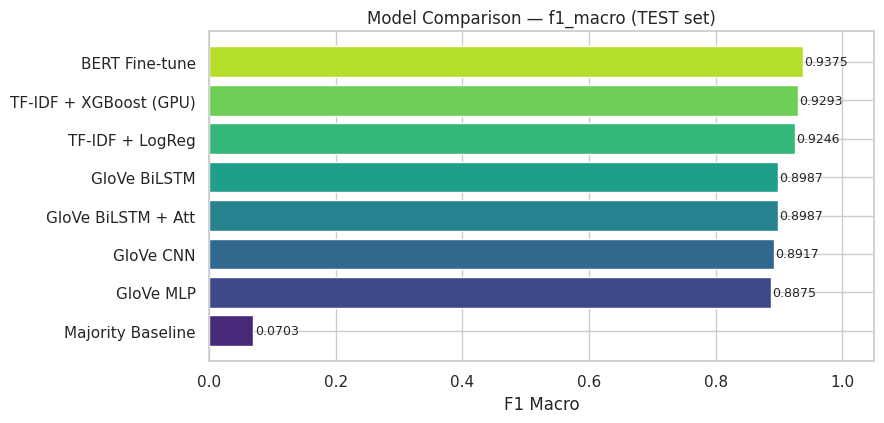

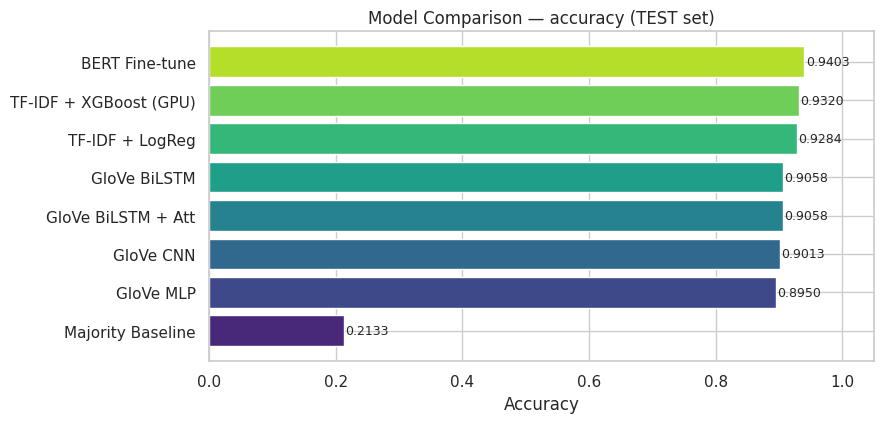

In [ ]:
# ── 11.3 Bar Chart Comparison ─────────────────────────────────────────────────
plot_model_comparison(RESULTS, metric="f1_macro", split="test")
plot_model_comparison(RESULTS, metric="accuracy", split="test")

Perform error analysis on the BERT fine-tuned model by displaying the top 10 misclassified test samples, helping to understand common mistakes and challenging cases.

In [ ]:
# ── 11.4 Error Analysis — Top Misclassified Samples ──────────────────────────
print("=== Error Analysis — BERT Fine-tune ===")
display(error_analysis(df_test, y_test, trf_test_preds, le, n=10))

=== Error Analysis — BERT Fine-tune ===


,tweet_text,true_label,pred_label
5,@NewEraJihadi @ShamiAnalyst You seem to have a...,not_cyberbullying,religion
26,"RT @harikondabolu: In his #Ferguson testimony,...",religion,gender
35,@TheRealFattLaff It's even more annoying that ...,not_cyberbullying,ethnicity
51,"If Jill Biden came out and said, ""Schools shou...",age,not_cyberbullying
60,After watching the Shia militia beat a Peshmer...,religion,not_cyberbullying
66,@kimberly_abraha @tom_dodsworth @pinkdevil_131...,not_cyberbullying,gender
70,@calcetin13 @boxedariel First hand account fr...,gender,not_cyberbullying
92,I'm still bad at flirting with ladies. My game...,gender,not_cyberbullying
93,"@S_Elhussieny you, yes you, are the one who pl...",gender,not_cyberbullying
105,@Ammaawah @jm111t So you are not insulted when...,not_cyberbullying,religion


Save all trained models, tokenizers, vectorizers, and relevant artifacts to disk to ensure reproducibility and enable future use without retraining.

In [ ]:
# ── 12.1 Save All Artefacts ───────────────────────────────────────────────────
save_artefacts()

Artefacts saved  ->  outputs/metrics  |  models/shared


Extract CLS-token embeddings from the fine-tuned BERT model for all test samples, creating a matrix of fixed-size vector representations

In [ ]:
device = trainer.args.device
model = trainer.model
model.eval()

test_loader = DataLoader(trf_ds_test, batch_size=32, shuffle=False)

bert_embeddings_list = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        outputs = model.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        cls_embeddings = outputs.last_hidden_state[:, 0, :]  # CLS token
        bert_embeddings_list.append(cls_embeddings.cpu().numpy())

bert_embeddings = np.vstack(bert_embeddings_list)

print("Fine-tuned BERT embeddings shape:", bert_embeddings.shape)

Fine-tuned BERT embeddings shape: (5541, 768)


Generate sentence embeddings for the test set using the pre-trained SBERT model (all-MiniLM-L6-v2), producing fixed-size vector representations of each text

Compute dense sentence embeddings for the test set using the pre-trained SBERT model (all-MiniLM-L6-v2), producing fixed-size vector representations suitable for clustering, similarity comparisons, or downstream tasks.

In [ ]:
sbert_model = SentenceTransformer("all-MiniLM-L6-v2")

sbert_embeddings = sbert_model.encode(
    list(X_test_raw),
    show_progress_bar=True
)

print("SBERT embeddings shape:", sbert_embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/174 [00:00<?, ?it/s]

SBERT embeddings shape: (5541, 384)


Reduce the dimensionality of SBERT and fine-tuned BERT embeddings to 2D using UMAP, enabling visualization of the embedding space and comparison of text representations.

In [ ]:
umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric="cosine",
    random_state=42
)

sbert_2d = umap_model.fit_transform(sbert_embeddings)
bert_2d  = umap_model.fit_transform(bert_embeddings)

Visualize the 2D UMAP projections of the SBERT and fine-tuned BERT embeddings side by side. Each point represents a test sample, colored according to its cyberbullying class. This allows comparison of how well the pre-trained SBERT embeddings and the fine-tuned BERT embeddings separate the different classes in the reduced 2D space, highlighting the effect of fine-tuning on class separability and cluster formation.

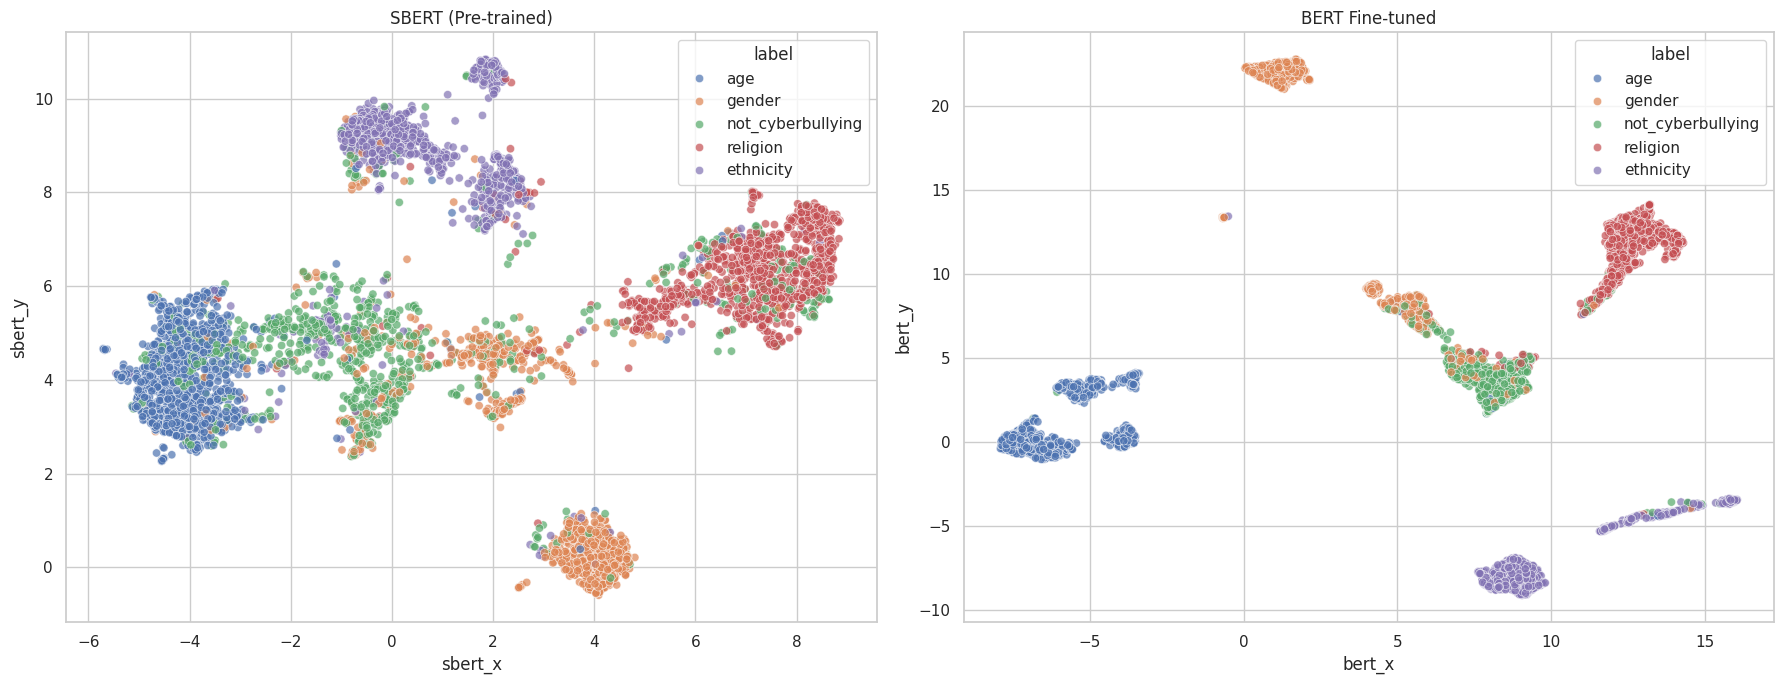

In [ ]:


df_plot = pd.DataFrame({
    "sbert_x": sbert_2d[:, 0],
    "sbert_y": sbert_2d[:, 1],
    "bert_x":  bert_2d[:, 0],
    "bert_y":  bert_2d[:, 1],
    "label": le.inverse_transform(y_test)
})

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.scatterplot(
    x="sbert_x", y="sbert_y",
    hue="label",
    data=df_plot,
    alpha=0.7,
    ax=axes[0]
)
axes[0].set_title("SBERT (Pre-trained)")

sns.scatterplot(
    x="bert_x", y="bert_y",
    hue="label",
    data=df_plot,
    alpha=0.7,
    ax=axes[1]
)
axes[1].set_title("BERT Fine-tuned")

plt.tight_layout()
plt.show()

Generate dense sentence embeddings for the test set using the pre-trained SBERT model (all-MiniLM-L6-v2), producing fixed-size vector representations

In [ ]:
sbert_model = SentenceTransformer("all-MiniLM-L6-v2")
emb_sbert = sbert_model.encode(X_test_raw, show_progress_bar=True)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/174 [00:00<?, ?it/s]

Extract embeddings from the fine-tuned BERT model for the test set using the CLS token. These embeddings capture contextualized representations of each text after task-specific fine-tuning, suitable for downstream analysis, clustering, or similarity tasks.

In [ ]:


bert_model = AutoModel.from_pretrained(str(CFG["model_dir"] / "transformer_best"))
bert_model.eval()
bert_model.to("cuda")
emb_bert_ft = get_bert_embeddings(X_test_raw, trf_tokenizer, bert_model, CFG["max_len"])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: models/transformer_best
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Compute clustering quality metrics for the test set embeddings: Silhouette score measures how well samples are separated from other classes, and Davies-Bouldin score measures cluster compactness and separation. Comparing SBERT (pre-trained) and fine-tuned BERT embeddings shows that fine-tuning improves class separability in the embedding space.

In [ ]:

sil_sbert = silhouette_score(emb_sbert, y_test)
db_sbert  = davies_bouldin_score(emb_sbert, y_test)

sil_bert_ft = silhouette_score(emb_bert_ft, y_test)
db_bert_ft  = davies_bouldin_score(emb_bert_ft, y_test)

print(f"SBERT pre-trained: Silhouette={sil_sbert:.3f}, Davies-Bouldin={db_sbert:.3f}")
print(f"BERT fine-tuned : Silhouette={sil_bert_ft:.3f}, Davies-Bouldin={db_bert_ft:.3f}")

SBERT pre-trained: Silhouette=0.062, Davies-Bouldin=4.333
BERT fine-tuned : Silhouette=0.635, Davies-Bouldin=0.708


The metrics clearly show that fine-tuning BERT greatly improves the structure of the embedding space. SBERT’s pre-trained embeddings have a very low Silhouette score (0.062) and high Davies-Bouldin score (4.333), indicating poor separation and overlapping clusters. In contrast, the fine-tuned BERT embeddings achieve a much higher Silhouette score (0.635) and a much lower Davies-Bouldin score (0.708), reflecting well-separated, compact clusters aligned with the true classes.

Extract the embeddings of all BERTopic topics (excluding outliers) and organize them into a NumPy array, preparing them for similarity calculations

In [ ]:
topic_ids = set(topics) - {-1}
# Use BERTopic's internal topic embeddings directly for consistency
topic_embeddings_dict = {topic_id: topic_model.topic_embeddings_[topic_id] for topic_id in topic_ids}

# Convert to numpy array for cosine_similarity
topic_keys = list(topic_embeddings_dict.keys())
emb_matrix = np.array([topic_embeddings_dict[t] for t in topic_keys])

Compute pairwise cosine similarities between BERTopic topic embeddings and extract all topic pairs with similarity above a defined threshold (0.5), creating a list of edges that can be used for graph-based analysis or identifying closely related topics.

In [ ]:
sim_matrix = cosine_similarity(emb_matrix)

threshold = 0.5
edges = []
for i in range(len(topic_keys)):
    for j in range(i+1, len(topic_keys)):
        if sim_matrix[i, j] >= threshold:
            edges.append((topic_keys[i], topic_keys[j], sim_matrix[i, j]))

This visualization builds a network graph of the most representative topics discovered by BERTopic, focusing on the top three topics per cyberbullying class. Each node represents a topic, sized according to the number of documents it contains and colored by its dominant class. Edges connect topics with high cosine similarity in the embedding space, with edge thickness proportional to similarity strength. The node labels display the top three words of each topic for quick interpretability. This network highlights how topics cluster by class, which topics are closely related, and how semantic relationships between topics can be visualized in an interpretable, class-aware layout, providing a comprehensive overview of the structure of the “other cyberbullying” category in the embedding space.

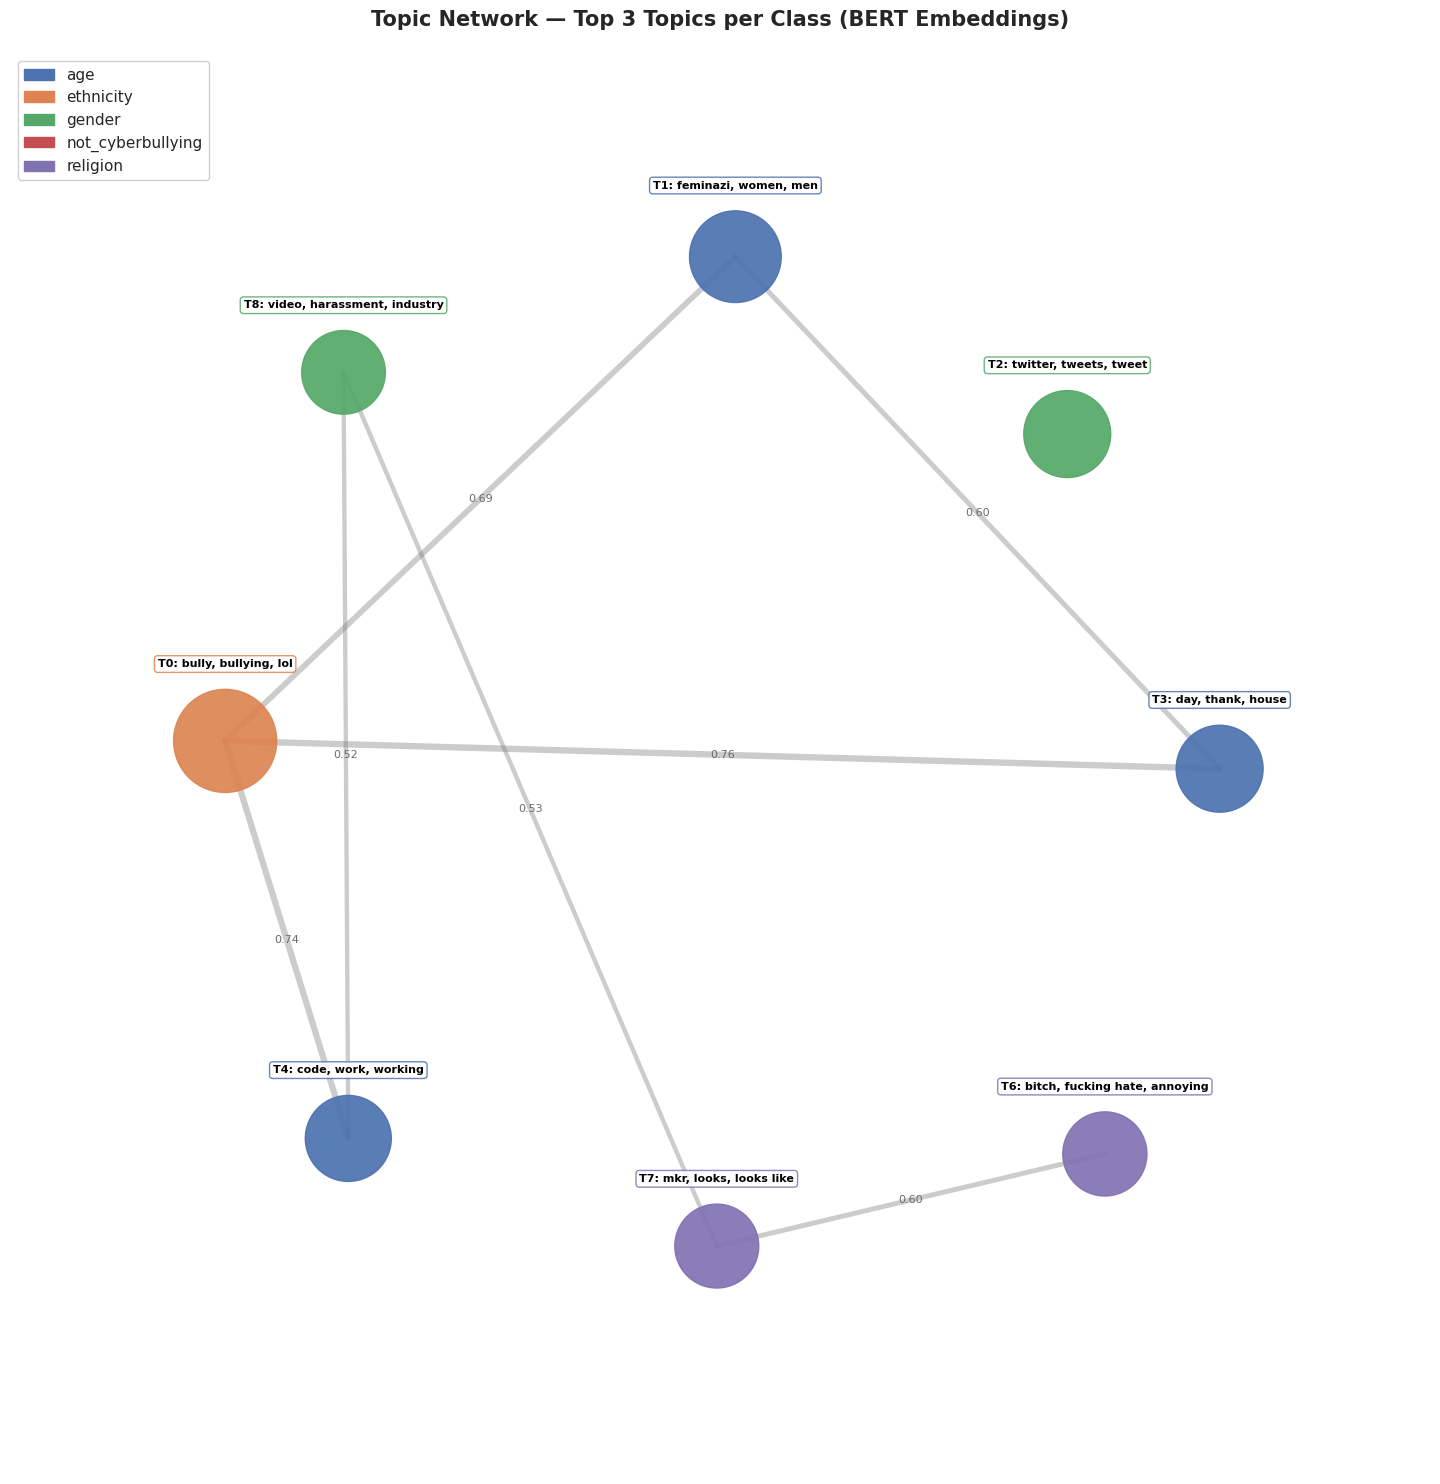

In [ ]:


class_names = le.classes_.tolist()
class_colors = {cls: _plots.COLORS[i] for i, cls in enumerate(class_names)}


topic_freq = topic_model.get_topic_info()
topic_freq = topic_freq.set_index("Topic").loc[sorted(topic_freq.Topic.unique()), :]
sizes = topic_freq['Count'].tolist()  # dimensione topic

df_plot_temp = pd.DataFrame({
    'label': le.inverse_transform(y_test[:len(new_topics)])
})

doc_topics = pd.DataFrame({
    'document': df_other['clean_text'].reset_index(drop=True),
    'topic': new_topics,
    'label': df_plot_temp['label']
})


topic_dominant_class = doc_topics.groupby('topic')['label'] \
    .agg(lambda x: x.mode()[0] if not x.mode().empty else None) \
    .to_dict()
if -1 in topic_dominant_class:
    del topic_dominant_class[-1]


top_nodes = {}
for cls in class_names:
    cls_topics = [(t, sizes[topics.index(t)])
                  for t, c in topic_dominant_class.items()
                  if c == cls and t in topics]
    cls_topics_sorted = sorted(cls_topics, key=lambda x: x[1], reverse=True)[:3]
    top_nodes[cls] = [t for t, _ in cls_topics_sorted]

selected_topics = [(t, cls) for cls, ts in top_nodes.items() for t in ts]
selected_idxs   = [topics.index(t) for t, _ in selected_topics]


embeddings_array = np.array(topic_model.topic_embeddings_)
selected_embeddings = embeddings_array[selected_idxs]
sim_matrix_sel  = cosine_similarity(selected_embeddings)

G = nx.Graph()
for t, cls in selected_topics:
    top_words = topic_model.get_topic(t)
    top_words_str = ", ".join([w for w, _ in top_words[:3]])
    G.add_node(t, cls=cls, size=sizes[topics.index(t)], label=f"T{t}: {top_words_str}")

K = 2
n = len(selected_topics)
for i in range(n):
    top_k = np.argsort(sim_matrix_sel[i])[::-1][1:K+1]
    for j in top_k:
        if j > i:
            t_i = selected_topics[i][0]
            t_j = selected_topics[j][0]
            G.add_edge(t_i, t_j, weight=float(sim_matrix_sel[i, j]))


pos = nx.spring_layout(G, k=4, seed=42)


fig, ax = plt.subplots(figsize=(20, 15))


for u, v, data in G.edges(data=True):
    x = [pos[u][0], pos[v][0]]
    y = [pos[u][1], pos[v][1]]
    ax.plot(x, y, color='gray', alpha=0.4, linewidth=data['weight'] * 6, zorder=1)

    mx, my = (pos[u][0]+pos[v][0])/2, (pos[u][1]+pos[v][1])/2
    ax.text(mx, my, f"{data['weight']:.2f}", fontsize=8, ha='center',
            va='center', color='dimgray', zorder=3)


node_radius = 0.08
for t, cls in selected_topics:
    x, y = pos[t]
    color = class_colors[cls]
    size  = G.nodes[t]['size']
    label = G.nodes[t]['label']


    circle = plt.Circle((x, y), node_radius + size/80000,
                        color=color, zorder=2, alpha=0.92)
    ax.add_patch(circle)

    ax.text(x, y + node_radius + size/80000 + 0.04, label,
            fontsize=8, ha='center', va='bottom',
            fontweight='bold', color='black',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor=color, alpha=0.85),
            zorder=4)


legend_patches = [mpatches.Patch(color=color, label=cls)
                  for cls, color in class_colors.items()]
ax.legend(handles=legend_patches, loc='upper left', fontsize=11, framealpha=0.9)


ax.set_title("Topic Network — Top 3 Topics per Class (BERT Embeddings)",
             fontsize=15, fontweight='bold', pad=20)
ax.set_aspect('equal')
ax.axis('off')
ax.set_xlim(-1.4, 1.4)
ax.set_ylim(-1.4, 1.4)
plt.tight_layout()


img_path = OUTPUT_DIR / "topic_network_top3.png"
plt.savefig(str(img_path), dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# Section 18: BERT Inference

Load the pre-trained BERT model and tokenizer from the Hugging Face hub, ready for evaluation on CPU or GPU

In [ ]:
repo_id = "mattematics/BERT"
tokenizer = AutoTokenizer.from_pretrained(repo_id)
model = AutoModelForSequenceClassification.from_pretrained(repo_id)
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/322 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

Example of running inference on a single input text and obtaining the predicted class label.

In [ ]:
text = "This is a test message for cyberbullying detection."

inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=256)
inputs = {k: v.to(device) for k,v in inputs.items()}

with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits
    pred_label_id = torch.argmax(logits, dim=1).item()

print("Predicted class ID:", pred_label_id)

Predicted class ID: 3


In [ ]:
label_list = le.classes_
print("Predicted class:", label_list[pred_label_id])

Predicted class: not_cyberbullying


Example of running inference on multiple texts at once, converting model outputs to readable class labels.

In [ ]:
texts = [
    "Stop sending me messages!",
    "I love your posts, keep it up!"
]

inputs = tokenizer(texts, return_tensors="pt", truncation=True, padding=True, max_length=256)
inputs = {k: v.to(device) for k,v in inputs.items()}

with torch.no_grad():
    outputs = model(**inputs)
    preds = torch.argmax(outputs.logits, dim=1)

pred_classes = [label_list[i] for i in preds.cpu().numpy()]
print(pred_classes)

['not_cyberbullying', 'not_cyberbullying']
